In [1]:
import sys, os
from pathlib import Path
from pprint import pprint
from collections import defaultdict

import numpy as np
import torch
import networkx as nx
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib import cm

from sklearn.metrics import precision_recall_fscore_support#confusion_matrix

import yaml

BASE_DIR = Path.cwd().resolve().parent.parent
sys.path.append(str(BASE_DIR))
SCRIPT_DIR = Path.cwd().resolve()
CFG_DIR = SCRIPT_DIR / 'configs'
RESULTS_DIR = SCRIPT_DIR / 'results'


from src.models.lr_ssd.snn__logn_gtv import SNN__LOGN_GTV
from src.models.tucker_decomp.hosvd import hosvd
from src.metrics.estimate_rank import estimate_tucker_rank

from src.multilinear_ops.mode_product import mode_product

from src.gsp.gsp_vis import draw_graph_signal
# Class used to import Server Machine Dataset and NYC Taxi Dataset with 
# Spatial and Temporal Graphs
from data.server_machine_dataset import SMDMachineChannel
from data.nyc_taxi_dataset import NYCTaxiDataset

plt.style.use('seaborn-v0_8-paper')
# Set the default font family to serif
plt.rcParams['font.family'] = 'serif' 
# Specify a list of font names to try for the serif family
plt.rcParams['font.serif'] = ['Times New Roman', 'DejaVu Serif', 'Palatino'] 

Let's import SMD Dataset, Machine 1 Channel 1 processed into a tensor

In [ ]:
mchannel = SMDMachineChannel(1,1, mean_modes=[1,3])
print("Features, Days, Hours, Minutes")
print(mchannel.Y.shape)

Features, Days, Hours, Minutes
(38, 20, 24, 60)


## Exploratory Data Analysis for Server Machine Dataset
`SMDMachineChannel` Class calculates a 2-NN graph for the features. Below, I showcased the learned graph for Machine 1, Channel 3. I also plotted the means of the dataset across different dimensions. It looks like there is a functional relation between the mean of the features across different hours of the day as it is the smoothest.

Y shape:(38, 17, 24, 60)
	(Features, Days, Hours, Minutes)


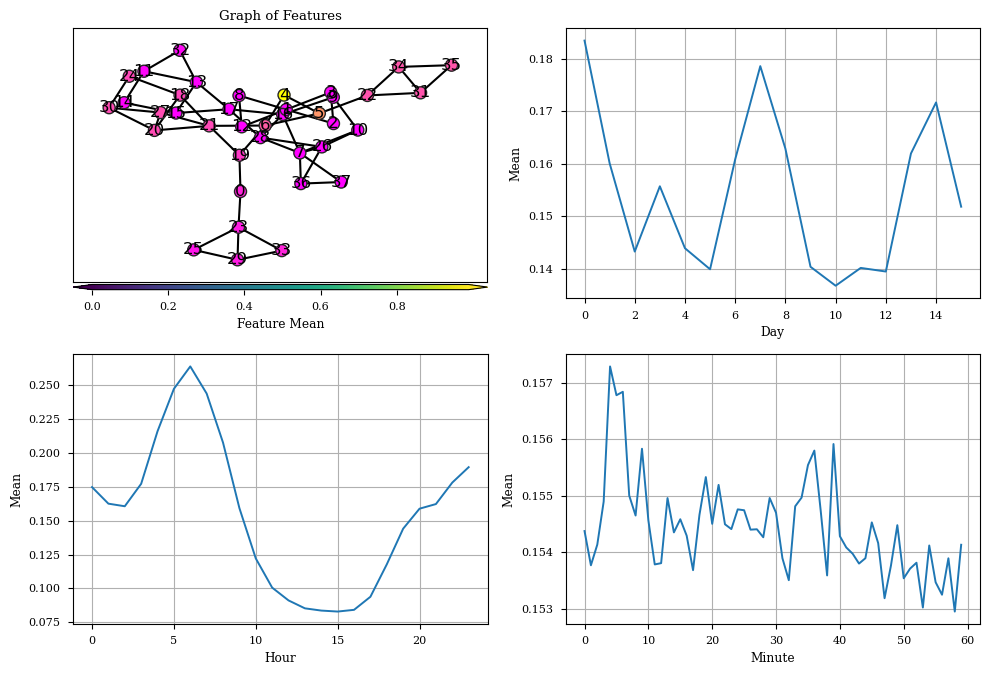

(<Figure size 1000x700 with 5 Axes>,
 <Axes: title={'center': 'Graph of Features'}>)

In [22]:
mchannel = SMDMachineChannel(1,3, )
Y = mchannel.Y
print(f"Y shape:{Y.shape}\n\t(Features, Days, Hours, Minutes)")

fig, axes = plt.subplots(2, 2, figsize=(10, 7))
axes = axes.flatten()

mode_names = ["Day", "Hour", "Minute"]

for i in range(1, 4):
    y = mchannel.mode_wise_means[i].ravel()
    x = np.arange(len(y))
    axes[i].plot(x,y)
    # axes[i].set_title(f"Feature {i+1}")
    axes[i].set_xlabel(mode_names[i-1])
    axes[i].set_ylabel("Mean")
    axes[i].grid()

axes[0].set_title("Graph of Features");
draw_graph_signal(mchannel.G, mchannel.mode_wise_means[0].reshape((-1,1)),
                fig=fig, ax=axes[0], legend_on=False, layout='kamada_kawai',
                y_label='Feature Mean', suptitle=None, node_size=75)


## Noise and Multi-linear Rank Estimation
Here, I estimate the multi-linear rank of the tensor of observations using different methods. Please refer to `estimeate_tucker_rank` function for the details. After this, I estimate a noise level with additive gaussian white noise with constant variance (I did not do hypothesis testing for this. A more careful approach could account for heteroscedasticity). This noise level is used for hyper-parameter selection for the models.

defaultdict(<class 'list'>,
            {'centered_1': [{'estimated_ranks': [32, 20, 24, 60],
                             'num_param': 921792.0,
                             'r2_value': 1.0,
                             'residual_energy': 0.0}],
             'centered_1_r2thr': [{'estimated_ranks': [12, 20, 24, 42],
                                   'num_param': 242988.0,
                                   'r2_value': 0.9901349178195173,
                                   'residual_energy': 72.29438256992307}],
             'fh_centered_1': [{'estimated_ranks': [32, 20, 24, 60],
                                'num_param': 921792.0,
                                'r2_value': 1.0,
                                'residual_energy': 0.0}],
             'fh_centered_1_r2thr': [{'estimated_ranks': [13, 20, 24, 43],
                                      'num_param': 269376.0,
                                      'r2_value': 0.9900085908112255,
                                      'resid

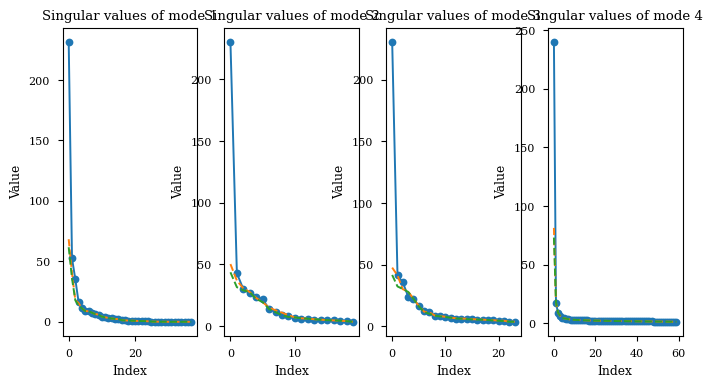

In [21]:
ch = [1]#, 2, 3, 4, 5, 6, 7, 8]

rank_estimates = defaultdict(list)
fig, axes = plt.subplots(1,4, figsize=(8, 4))
for i, ch in enumerate(ch):
    
    mchannel = SMDMachineChannel(1,ch, center_data=False)
    Y = mchannel.Y
    hosvd_decomp = hosvd(Y)
    svals = hosvd_decomp['svals']

    
    raw_estimation_result = estimate_tucker_rank(Y, method='GCV')
    rank_estimates[f'raw_{ch}'].append(raw_estimation_result)
    rank_estimates[f'raw_{ch}_r2thr'].append(estimate_tucker_rank(Y, method='core_thresholding', r2_thr=0.99))
    mchannel = SMDMachineChannel(1,ch, center_data=True)
    Y = mchannel.Y
    
    hosvd_decomp = hosvd(Y)
    centered_svals = hosvd_decomp['svals']
    rank_estimates[f'centered_{ch}'].append(estimate_tucker_rank(Y, method='GCV'))
    rank_estimates[f'centered_{ch}_r2thr'].append(estimate_tucker_rank(Y, method='core_thresholding', r2_thr=0.99))

    mchannel = SMDMachineChannel(1,ch, center_data=True, mean_modes=[1,3])
    Y = mchannel.Y
    
    hosvd_decomp = hosvd(Y)
    fd_centered_svals = hosvd_decomp['svals']
    rank_estimates[f'fh_centered_{ch}'].append(estimate_tucker_rank(Y, method='GCV'))
    rank_estimates[f'fh_centered_{ch}_r2thr'].append(estimate_tucker_rank(Y, method='core_thresholding', r2_thr=0.99))
    for j in range(4):
        ax = axes[j]
        ax.plot(svals[j].cpu().numpy(), label=f'Ch: {ch}', marker='o', linestyle='-')
        ax.plot(centered_svals[j].cpu().numpy(), label=f'Centered Ch: {ch}', marker='x', linestyle='--')
        ax.plot(fd_centered_svals[j].cpu().numpy(), label=f'Centered Ch: {ch}', marker='+', linestyle='--')

for i, ax in enumerate(axes):
    ax.set_title(f'Singular values of mode {i+1}')
    ax.set_xlabel('Index')
    ax.set_ylabel('Value')
pprint(rank_estimates)

defaultdict(<class 'list'>,
            {'centered_1': [{'estimated_ranks': [32, 20, 24, 60],
                             'num_param': 921792.0,
                             'r2_value': 1.0,
                             'residual_energy': 0.0}],
             'centered_1_r2thr': [{'estimated_ranks': [12, 20, 24, 42],
                                   'num_param': 242988.0,
                                   'r2_value': 0.9901349178195169,
                                   'residual_energy': 72.29438256992853}],
             'fh_centered_1': [{'estimated_ranks': [32, 20, 24, 60],
                                'num_param': 921792.0,
                                'r2_value': 1.0,
                                'residual_energy': 0.0}],
             'fh_centered_1_r2thr': [{'estimated_ranks': [13, 20, 24, 43],
                                      'num_param': 269376.0,
                                      'r2_value': 0.9900085908112255,
                                      'resid

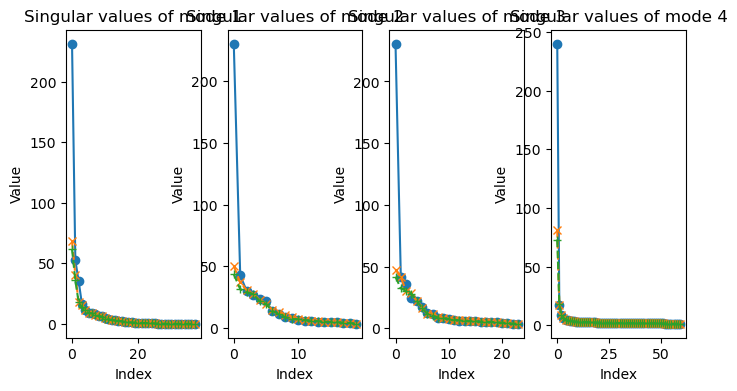

In [21]:
ch = [1]#, 2, 3, 4, 5, 6, 7, 8]

rank_estimates = defaultdict(list)
fig, axes = plt.subplots(1,4, figsize=(8, 4))
for i, ch in enumerate(ch):
    
    mchannel = SMDMachineChannel(1,ch, center_data=False)
    Y = mchannel.Y
    hosvd_decomp = hosvd(Y)
    svals = hosvd_decomp['svals']

    
    raw_estimation_result = estimate_tucker_rank(Y, method='GCV')
    rank_estimates[f'raw_{ch}'].append(raw_estimation_result)
    rank_estimates[f'raw_{ch}_r2thr'].append(estimate_tucker_rank(Y, method='core_thresholding', r2_thr=0.99))
    mchannel = SMDMachineChannel(1,ch, center_data=True)
    Y = mchannel.Y
    
    hosvd_decomp = hosvd(Y)
    centered_svals = hosvd_decomp['svals']
    rank_estimates[f'centered_{ch}'].append(estimate_tucker_rank(Y, method='GCV'))
    rank_estimates[f'centered_{ch}_r2thr'].append(estimate_tucker_rank(Y, method='core_thresholding', r2_thr=0.99))

    mchannel = SMDMachineChannel(1,ch, center_data=True, mean_modes=[1,3])
    Y = mchannel.Y
    
    hosvd_decomp = hosvd(Y)
    fd_centered_svals = hosvd_decomp['svals']
    rank_estimates[f'fh_centered_{ch}'].append(estimate_tucker_rank(Y, method='GCV'))
    rank_estimates[f'fh_centered_{ch}_r2thr'].append(estimate_tucker_rank(Y, method='core_thresholding', r2_thr=0.99))
    for j in range(4):
        ax = axes[j]
        ax.plot(svals[j].cpu().numpy(), label=f'Ch: {ch}', marker='o', linestyle='-')
        ax.plot(centered_svals[j].cpu().numpy(), label=f'Centered Ch: {ch}', marker='x', linestyle='--')
        ax.plot(fd_centered_svals[j].cpu().numpy(), label=f'Centered Ch: {ch}', marker='+', linestyle='--')

for i, ax in enumerate(axes):
    ax.set_title(f'Singular values of mode {i+1}')
    ax.set_xlabel('Index')
    ax.set_ylabel('Value')
pprint(rank_estimates)

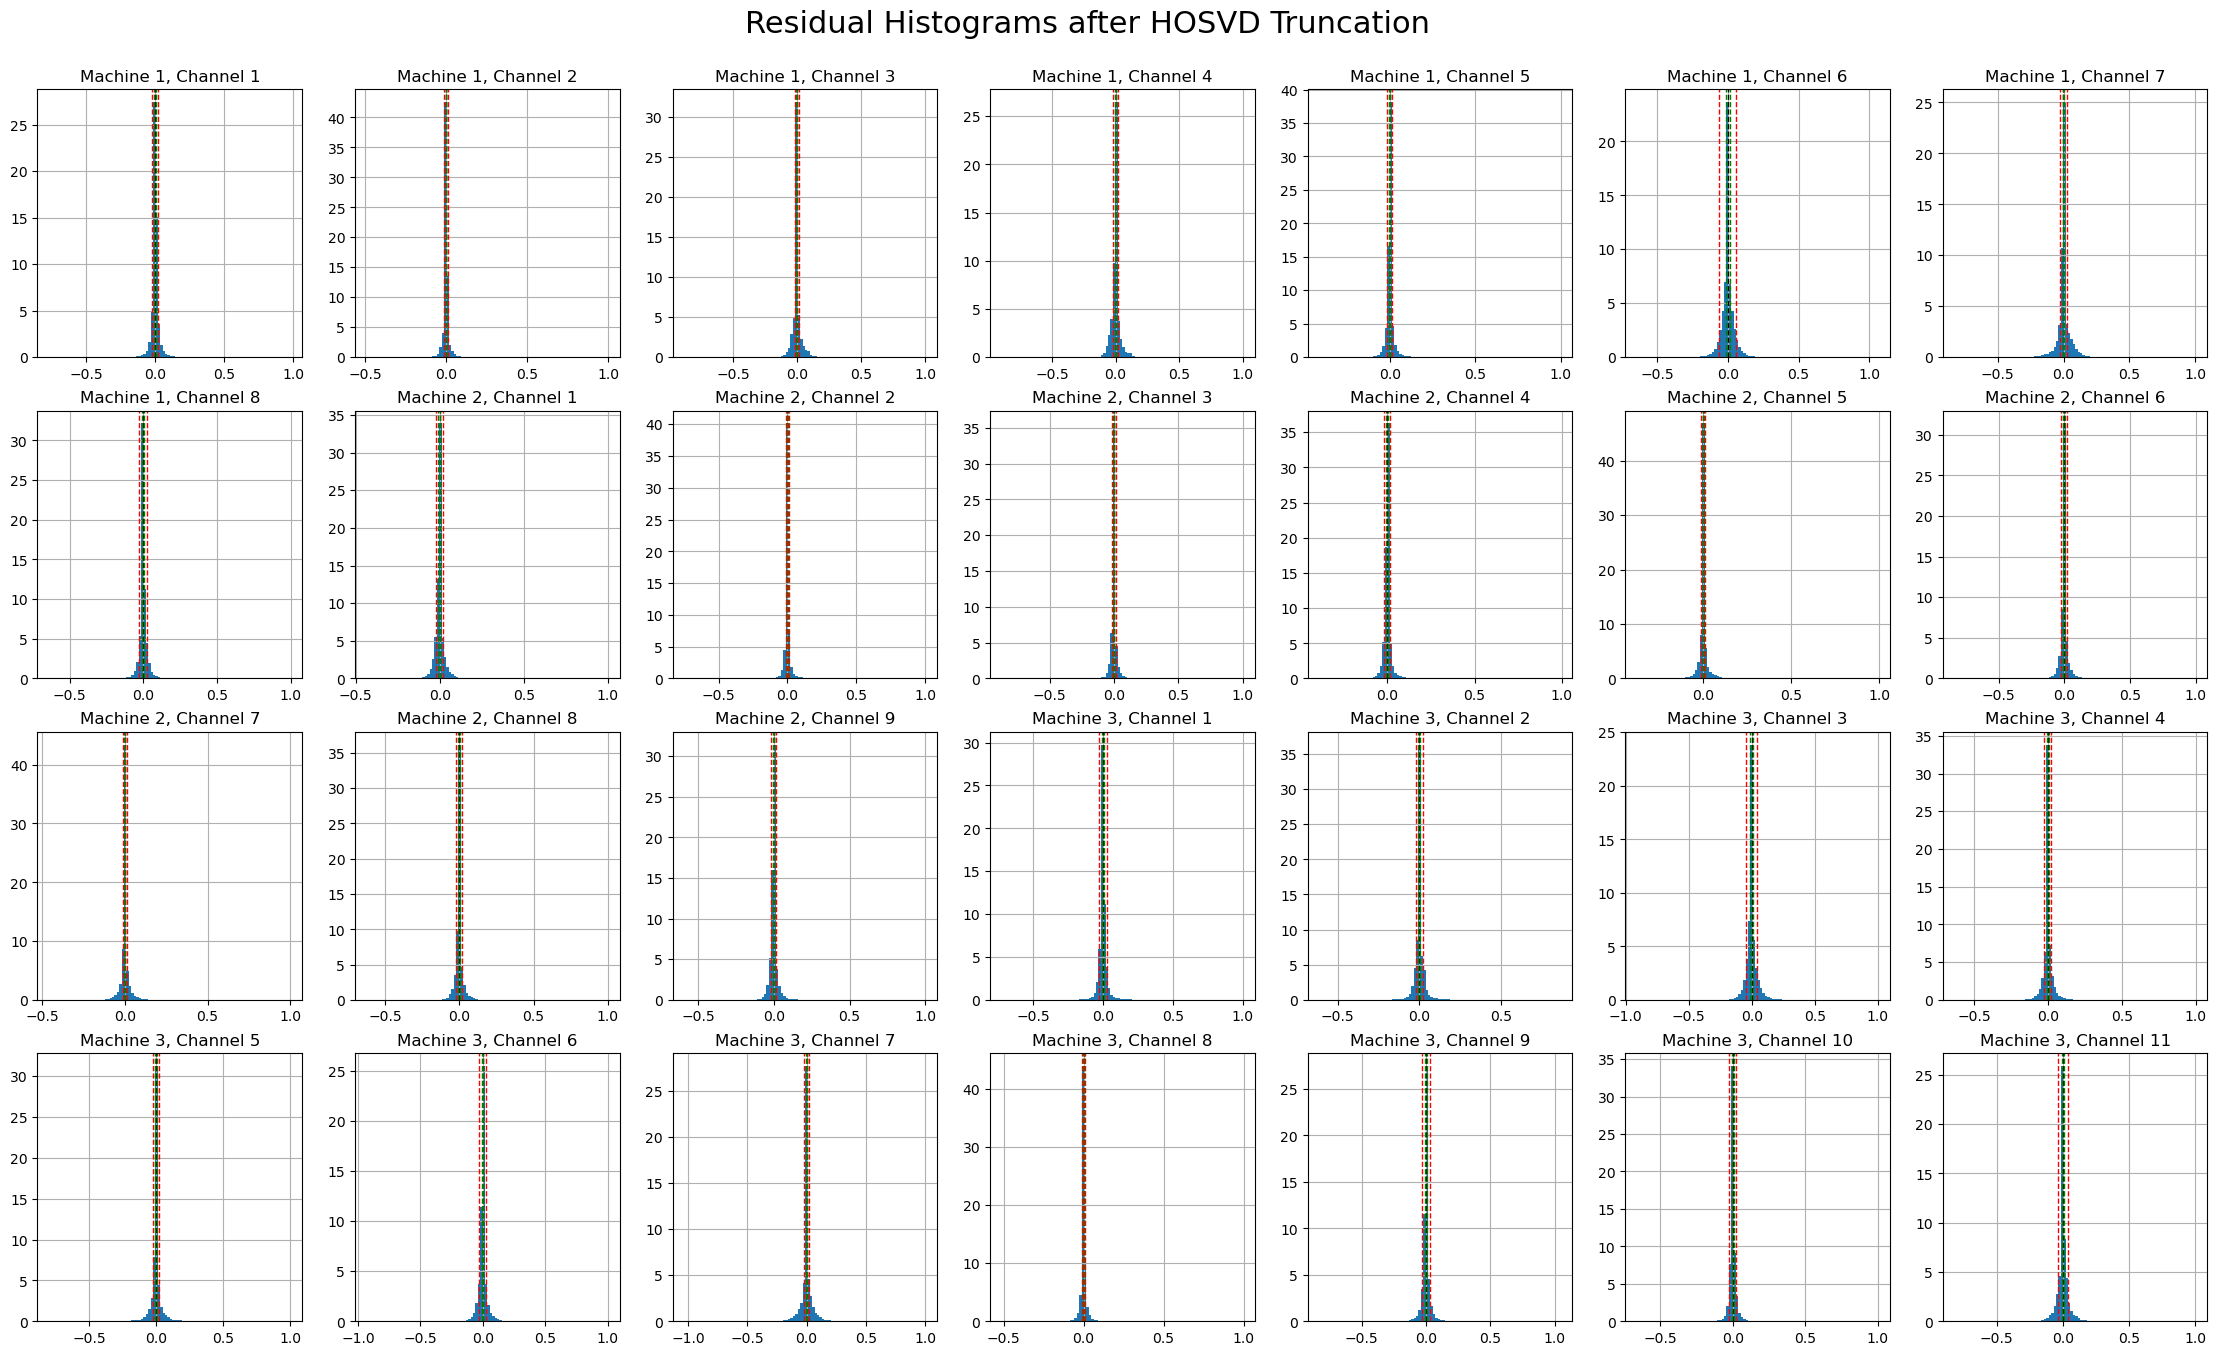

In [4]:
r2_thr = 0.98
machines = [1,2,3]
m_n_channels = {1:8, 2:9, 3:11}

rank_estimates = {'GCV': defaultdict(lambda: defaultdict(list)),
                  'R2': defaultdict(lambda: defaultdict(list))}

fig, axes = plt.subplots(nrows=4, ncols=7, figsize=(28, 16))
axes = axes.flatten()
k = 0
for m in machines:
    for ch in range(1, m_n_channels[m]+1):
        mchannel = SMDMachineChannel(m, ch, center_data=False, mean_modes=[1,3])
        Y = mchannel.Y
        D = np.prod(Y.shape)
        
        rank_estimates['GCV'][m][ch].append(estimate_tucker_rank(Y, method='GCV'))
        rank_estimates['R2'][m][ch].append(estimate_tucker_rank(Y, method='core_thresholding', r2_thr=r2_thr))
        
        core_dim = rank_estimates['R2'][m][ch][-1]['estimated_ranks']
        P = rank_estimates['R2'][m][ch][-1]['num_param']
        hosvd_decomp = hosvd(Y, core_dims=core_dim)
        
        truncated_Y = hosvd_decomp['core']
        for i, mode in enumerate([1, 2, 3, 4]):
            truncated_Y = mode_product(truncated_Y, hosvd_decomp['factors'][i], mode)
        
        residual_Y = Y - truncated_Y.cpu().numpy()
        median_res = np.median(residual_Y.ravel())
        Q1 = np.quantile(residual_Y.ravel(), 0.25)
        Q3 = np.quantile(residual_Y.ravel(), 0.75)
        IQR = Q3 - Q1
        outlier_labels = (residual_Y < Q1 - 1.5 * IQR) | (residual_Y > Q3 + 1.5 * IQR)
        non_outliers = residual_Y[~outlier_labels]
        rank_estimates['GCV'][m][ch][-1].update(mchannel.anomaly_scoring_score(np.abs(residual_Y)))
        rank_estimates['R2'][m][ch][-1].update(mchannel.anomaly_scoring_score(np.abs(residual_Y)))
        rank_estimates['GCV'][m][ch][-1].update(mchannel.anomaly_detection_score(outlier_labels))
        rank_estimates['R2'][m][ch][-1].update(mchannel.anomaly_detection_score(outlier_labels))
        rank_estimates['GCV'][m][ch][-1].pop('st_scores');
        rank_estimates['GCV'][m][ch][-1].pop('t_scores');
        rank_estimates['R2'][m][ch][-1].pop('st_scores')
        rank_estimates['R2'][m][ch][-1].pop('t_scores')
        variance_est = np.var(non_outliers)
        variance_est_corrected = variance_est * (D/(D - P))
        rank_estimates['GCV'][m][ch][-1]['variance_estimate']= variance_est_corrected
        rank_estimates['R2'][m][ch][-1]['variance_estimate']= variance_est_corrected
        axes[k].set_title(f'Machine {m}, Channel {ch}')
        axes[k].hist(residual_Y[mchannel.og_mask].ravel(), bins=100, density=True)
        axes[k].axvline(median_res, color='k', linestyle='dashed', linewidth=1, label='Median')
        axes[k].axvline(Q1, color='g', linestyle='dashed', linewidth=1, label='Q1')
        axes[k].axvline(Q3, color='g', linestyle='dashed', linewidth=1, label='Q3')
        axes[k].axvline(Q1-1.5*IQR, color='r', linestyle='dashed', linewidth=1, label='Q1 - 1.5*IQR')
        axes[k].axvline(Q3+1.5*IQR, color='r', linestyle='dashed', linewidth=1, label='Q3 + 1.5*IQR')

        axes[k].grid(True)
        k += 1
        
fig.suptitle('Residual Histograms after HOSVD Truncation', fontsize=22, y=0.93)
# pprint(rank_estimates)
machines = [[k for i in range(1, v+1)] for  k, v in m_n_channels.items()]
machines = [m for sublist in machines for m in sublist]
channels = [[i for i in range(1, v+1)] for  k, v in m_n_channels.items()]
channels = [ch for sublist in channels for ch in sublist]
methods = ['GCV']* len(machines) + ['R2']*len(machines)
arrays = [methods, machines*2, channels*2]
mindex = pd.MultiIndex.from_arrays(arrays, names=['Method', 'machine_id', 'channel_id'])
df_list = [rank_estimates[i][j][k] for i,j,k in mindex]
df_list = [i for sublist in df_list for i in sublist]  # Flatten the list
df = pd.DataFrame(df_list, index=mindex, columns=rank_estimates['GCV'][1][1][0].keys())

In [4]:
df.loc['R2']

estimated_ranks  num_param  r2_value  residual_energy  \
machine_id channel_id                                                           
1          1               [4, 9, 7, 1]      665.0  0.980281      1152.124649   
           2           [11, 17, 24, 34]   153773.0  0.980178       441.842687   
           3               [2, 4, 4, 1]      295.0  0.981796      1270.369885   
           4               [2, 4, 4, 1]      295.0  0.980962      1317.467445   
           5            [9, 12, 15, 12]    20472.0  0.980023       532.959152   
           6               [7, 9, 4, 1]      680.0  0.980224      2156.368303   
           7               [2, 2, 2, 1]      213.0  0.980408      2750.997136   
           8              [6, 10, 8, 2]     1466.0  0.980292       751.668112   
2          1            [6, 17, 24, 17]    42539.0  0.980536       713.765556   
           2            [7, 14, 19, 12]    23274.0  0.980001       575.414882   
           3               [3, 5, 4, 1]      364.0  0.980057       888.339220   
           4            [11, 16, 15, 7]    19299.0  0.980008       518.475220   
           5               [5, 8, 7, 2]     1032.0  0.980342       743.862507   
           6              [5, 10, 9, 1]      909.0  0.980104      1526.207148   
           7               [5, 8, 7, 2]     1032.0  0.980478       717.400292   
           8               [3, 5, 3, 1]      332.0  0.981745      1039.622161   
           9             [4, 15, 10, 1]     1010.0  0.980086       827.658156   
3          1              [6, 11, 8, 6]     3911.0  0.980061      1713.080899   
           2               [5, 8, 7, 5]     2031.0  0.980222      1156.801641   
           3               [2, 2, 2, 1]      213.0  0.980371      2147.875017   
           4            [7, 17, 24, 12]    35065.0  0.980474      1021.087045   
           5            [10, 14, 16, 3]     7341.0  0.980019      1908.854670   
           6               [3, 9, 8, 1]      607.0  0.980535      1659.340611   
           7               [3, 5, 4, 1]      379.0  0.983138      2715.785010   
           8            [5, 20, 23, 10]    23688.0  0.980066       713.503246   
           9              [5, 10, 8, 7]     3564.0  0.980335      1714.834631   
           10              [4, 8, 5, 1]      522.0  0.980152       868.465201   
           11              [4, 6, 5, 2]      671.0  0.980782      3103.811279   

                         au_prc    au_roc        f1     PA_F1  precision  \
machine_id channel_id                                                      
1          1           0.358019  0.833392  0.173515  0.173515   0.095000   
           2           0.160174  0.878340  0.044734  0.044734   0.022879   
           3           0.201819  0.713908  0.066639  0.066639   0.034468   
           4           0.206246  0.696111  0.058951  0.058951   0.030371   
           5           0.499183  0.965525  0.008438  0.008438   0.004237   
           6           0.586351  0.840301  0.282609  0.282805   0.164579   
           7           0.173342  0.642073  0.183790  0.183790   0.101194   
           8           0.299745  0.722603  0.062618  0.062618   0.032321   
2          1           0.129978  0.668929  0.094587  0.094664   0.049643   
           2           0.156625  0.578132  0.213744  0.213811   0.119665   
           3           0.521544  0.941369  0.022457  0.022457   0.011356   
           4           0.269175  0.726546  0.133696  0.133696   0.071637   
           5           0.321032  0.817629  0.079452  0.079452   0.041369   
           6           0.376585  0.775705  0.029131  0.029131   0.014781   
           7           0.521792  0.898640  0.034587  0.034587   0.017598   
           8           0.930422  0.998174  0.013558  0.013558   0.006826   
           9           0.271002  0.746773  0.115419  0.115419   0.061244   
3          1           0.336600  0.858572  0.021346  0.021346   0.010788   
           2           0.051860  0.541206  0.089396  0.089396   0.046789 

# NYC Taxi Dataset Exploratory Data Analysis
I repeat a similar analysis for NYC 2018 Yellow Taxi dataset which we have previously pre-processed and we load using the `NYCTaxiDataset` Class.
I create a spatial graph for the NYC Taxi Zones using the shapefile provided by TLC. Details can be found in the class implementation.
The pipeline is as follows:
1. Scaling step.
2. Estimating multi-linear rank of the drop-offs using several different methods.
3. Using the rank and the singular values to select nuclear-norm parameters. $\psi_i$
4. Performing Higher-order Singular Value Thresholding with estimated ranks and obtaining residuals
5. Using Median Absolute Deviation estimator to estimate the noise standard deviation on the scaled drop-offs. Which we estimated to be $\hat{\sigma}^2=0.0029$.

In [23]:
import sys, os
from pathlib import Path
from pprint import pprint
from copy import deepcopy
from tqdm import tqdm
from collections import defaultdict

import numpy as np
import torch
import networkx as nx
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib import cm

from sklearn.metrics import precision_recall_fscore_support#confusion_matrix

import yaml
from tqdm import tqdm

BASE_DIR = Path.cwd().resolve().parent.parent
sys.path.append(str(BASE_DIR))
SCRIPT_DIR = Path.cwd().resolve()
CFG_DIR = SCRIPT_DIR / 'configs'
RESULTS_DIR = SCRIPT_DIR / 'results'


from src.models.lr_ssd.snn__logn_gtv import SNN__LOGN_GTV
from src.models.tucker_decomp.hosvd import hosvd
from src.metrics.estimate_rank import estimate_tucker_rank

from src.metrics.metric_tracker import MetricTracker
from src.multilinear_ops.matricize import matricize
from src.multilinear_ops.tensorize import tensorize
from src.multilinear_ops.mode_product import mode_product

from src.gsp.gsp_vis import draw_graph_signal
from data.nyc_taxi_dataset import NYCTaxiDataset

Y shape:(81, 53, 7, 24)
	(Features, Weeks, Days, Hours)


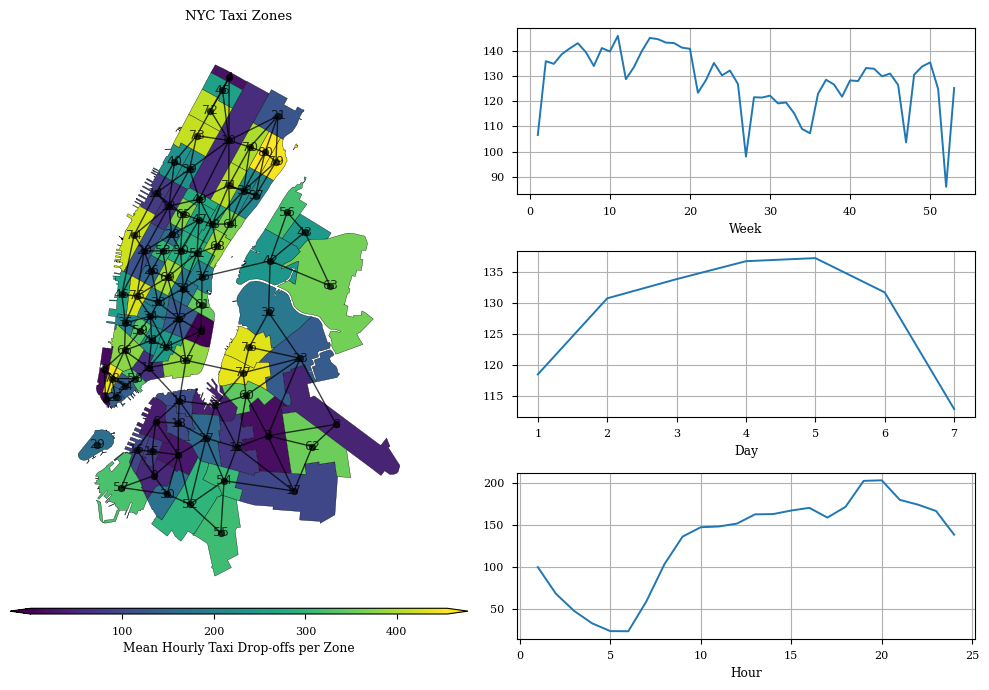

In [3]:

nyc_taxi = NYCTaxiDataset(edge_weighting={
    'method': 'rbf',
    'c': 0.05}
    )

Y = nyc_taxi.dropoffs
mode_wise_means = nyc_taxi._calculate_mode_wise_means(Y)
centered_Y = Y - np.mean(Y, axis=(1, 2), keepdims=True)
center_Y = np.mean(Y, axis=(1, 2), keepdims=True)
std_Y = np.std(Y, axis=(1, 2), keepdims=True)
print(f"Y shape:{Y.shape}\n\t(Features, Weeks, Days, Hours)")

fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(10, 7))

gs = axes[0, 0].get_gridspec()
# remove the underlying Axes
for ax in axes[:,0]:
    ax.remove()
axbig = fig.add_subplot(gs[:,0])
mode_names = ["Week", "Day", "Hour"]
 
for i in range(1, 4):
    y = mode_wise_means[i].ravel()
    x = np.arange(1, len(y)+1)
    axes[i-1,1].plot(x,y)
    axes[i-1,1].set_xlabel(mode_names[i-1])
    axes[i-1,1].grid()

y = mode_wise_means[0].ravel()
cmap = mpl.colormaps['viridis']
norm = cm.colors.Normalize(vmax=np.max(y), vmin=np.min(y))
smap = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
rgba_colors = cmap(norm(y))
std_rgba_colors = cmap(norm(std_Y.ravel()))
nyc_taxi.plot_zones(ax=axbig, fig=fig,
                    node_size=25, node_color='black',
                    graph_alpha=0.75,
                    zone_color=rgba_colors, 
                    zone_cmap=cmap,
                    zone_vmax=np.max(y),
                    zone_vmin=np.min(y))
fig.colorbar(smap,
             ax=axbig, orientation='horizontal',
             label='Mean Hourly Taxi Drop-offs per Zone',
             pad=0.01,fraction=0.05, aspect=80, location='bottom',
            extendrect=False, extend='both',
            )
fig.tight_layout()

In [ ]:
import numpy as np
import networkx as nx
from ipywidgets import interact, FloatSlider
from IPython.display import display

# Assuming nyc_taxi.G_nyc and nyc_taxi.Y are already defined
nodelist = list(nyc_taxi.G_nyc.nodes())
edgelist = list(nyc_taxi.G_nyc.edges())
B = nx.incidence_matrix(nyc_taxi.G_nyc, nodelist=nodelist, edgelist=edgelist, oriented=False).T
diffs = B @ matricize(nyc_taxi.Y, [1])
sigma_0 = np.sum(nyc_taxi.Y**2)
# Function to update weights based on sigma
def update_weights(c):
    weights = c/np.quantile(np.abs(diffs), 0.75, axis=1)
    # print(f"Sigma: {c*sigma_0:.2f}, coeff: {c}")
    print(f"Min: {weights.min()}, Max: {weights.max()}, Mean: {weights.mean()}, Std: {weights.std()}")
    G = nx.Graph()
    G.add_edges_from(edgelist)
    G.add_nodes_from(nodelist)
    for i, edge in enumerate(edgelist):
        G.edges[edge]['weight'] = weights[i]
    fig, ax = plt.subplots(figsize=(8, 6))
    nx.draw(G, pos=nyc_taxi.pos, ax=ax,
            node_size=25, node_color='black',
            edge_color=weights, edge_cmap=mpl.colormaps['inferno'],
            edge_vmin=weights.min(), edge_vmax=weights.max(),
            width=2, alpha=0.6)

# Create a slider widget for sigma
sigma_slider = FloatSlider(value=1.0, min=0.01, max=2, step=0.02, description='C:')
interact(update_weights, c=sigma_slider)

interactive(children=(FloatSlider(value=1.0, description='C:', max=2.0, min=0.01, step=0.02), Output()), _dom_…

<function __main__.update_weights(c)>

In [ ]:
import numpy as np
import networkx as nx
from ipywidgets import interact, FloatSlider
from IPython.display import display

# Assuming nyc_taxi.G_nyc and nyc_taxi.Y are already defined
nodelist = list(nyc_taxi.G_nyc.nodes())
edgelist = list(nyc_taxi.G_nyc.edges())
B = nx.incidence_matrix(nyc_taxi.G_nyc, nodelist=nodelist, edgelist=edgelist, oriented=False).T
diffs = B @ matricize(nyc_taxi.Y, [1])
sigma_0 = np.sum(nyc_taxi.Y**2)
# Function to update weights based on sigma
def update_weights(c):
    weights = -(diffs**2).sum(axis=1) / (2 * sigma_0*c)
    weights = np.exp(weights)
    print(f"Sigma: {c*sigma_0:.2f}, coeff: {c}")
    print(f"Min: {weights.min()}, Max: {weights.max()}, Mean: {weights.mean()}, Std: {weights.std()}")
    G = nx.Graph()
    G.add_edges_from(edgelist)
    G.add_nodes_from(nodelist)
    for i, edge in enumerate(edgelist):
        G.edges[edge]['weight'] = weights[i]
    fig, ax = plt.subplots(figsize=(8, 6))
    nx.draw(G, pos=nyc_taxi.pos, ax=ax,
            node_size=25, node_color='black',
            edge_color=weights, edge_cmap=mpl.colormaps['viridis'],
            edge_vmin=weights.min(), edge_vmax=weights.max(),
            width=2, alpha=0.6)

# Create a slider widget for sigma
sigma_slider = FloatSlider(value=1.0, min=0.01, max=2, step=0.02, description='C:')
interact(update_weights, c=sigma_slider)

interactive(children=(FloatSlider(value=1.0, description='C:', max=2.0, min=0.01, step=0.02), Output()), _dom_…

<function __main__.update_weights(c)>

In [45]:
def max_curvature_rank(s, smooth_window=3, logscale=True):
    """
    s: singular values (descending).
    Uses curvature on log(s) vs index; smoothing helps with noise.
    Returns: k (1-based), idx (0-based)
    """
    s = np.sort(np.asarray(s))[::-1]
    if logscale:
        y = np.log(np.maximum(s, 1e-12))
    else:
        y = s

    # simple moving average smoothing
    if smooth_window > 1:
        pad = smooth_window // 2
        y_pad = np.pad(y, (pad, pad), mode='edge')
        kernel = np.ones(smooth_window) / smooth_window
        y = np.convolve(y_pad, kernel, mode='valid')

    # discrete second derivative (curvature proxy)
    # curvature is large (more negative) at elbow on a decreasing spectrum
    d2 = np.zeros_like(y)
    d2[1:-1] = y[:-2] - 2*y[1:-1] + y[2:]
    idx = int(np.argmin(d2[1:-1]) + 1)  # avoid edges
    return idx + 1, idx

def kneedle_elbow(s, decreasing=True):
    """
    s: 1D array of singular values (not squared), unsorted or sorted.
    Returns: k (1-based rank), idx (0-based index).
    """
    s = np.asarray(s)
    s = np.sort(s)[::-1] if decreasing else np.sort(s)
    x = np.linspace(0, 1, len(s))
    y = (s - s.min()) / (s.max() - s.min() + 1e-12)  # normalize to [0,1]
    # Distance from the chord connecting endpoints
    # For decreasing spectra, the "knee" maximizes (y - line).
    line = x  # since endpoints mapped to (0,0) and (1,1)
    diff = y - line if decreasing else line - y
    idx = int(np.argmax(diff))
    return idx + 1, idx

Nuclear Norms: [1744.771421010989, 1596.5268142802277, 956.4929566558859, 1314.1330782689517]
Emres Mode Nuclear Norm Weights: [1.0, 1.0928544421583017, 1.8241341024727473, 1.327697666136901]
Invers Emres Weights: [1.0, 0.9150349409982527, 0.5482053093818194, 0.7531835187370799]
Concentration Weights: [1.0, 0.9318972112253455, 0.5511184586716849, 0.8008487994708209]
Normalized Concentration Weights: [1.0, 1.1520533382851164, 1.8747287801775085, 1.4712531898679988]
Angle with Dimension Weights: [5.924768470262914, 4.46616558791158, 0.9598930588843345, 2.5827657810677493]
Kneedle Ranks: [1, 1, 1, 1]
Kneedle Threshold Singular Values: [69.59753458787509, 46.78431022125406, 146.34792314354584, 121.23153137695716]
Normalized Kneedle Weights: [206.32938100599858, 131.51707389827925, 288.710748764616, 305.6407195933261]
Max Curvature Ranks: [14, 5, 6, 7]
Max Curvature Singular Values: [20.103069344262355, 30.84690148693303, 44.56169609944317, 30.75419894608321]
Max Curvature Thresholds: [19.5

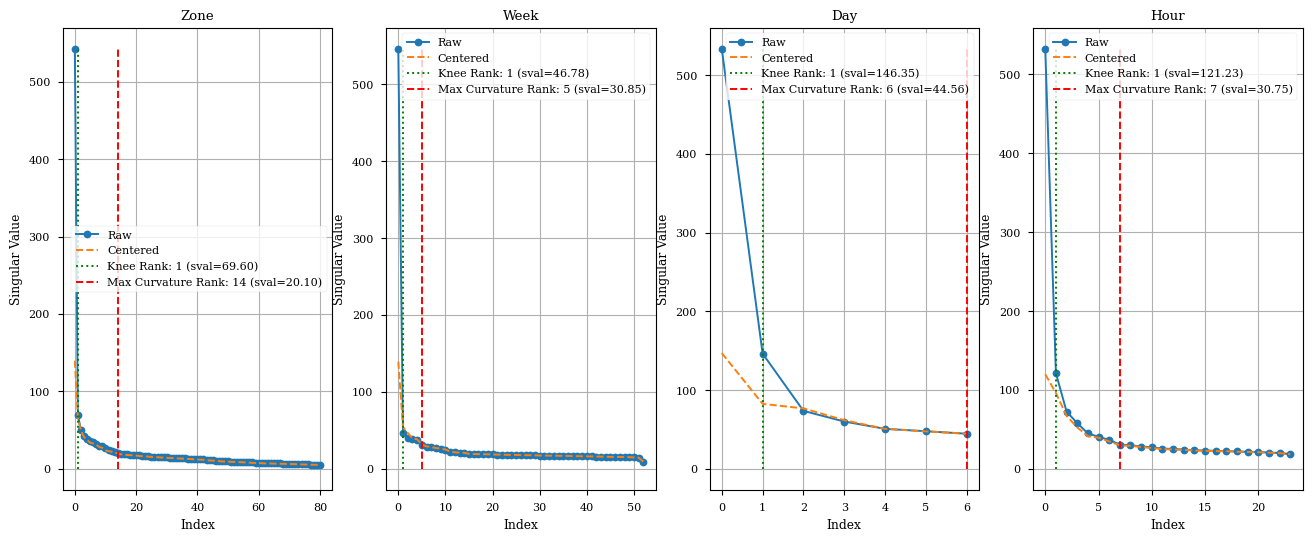

In [53]:
# ranges = (np.quantile( nyc_taxi.Y, 0.75, axis=(1,2), keepdims=True)
#            - np.quantile( nyc_taxi.Y, 0.25, axis=(1,2),keepdims=True))
ranges = (np.quantile( nyc_taxi.Y, 0.95, axis=(1,2), keepdims=True)
            # - np.quantile( nyc_taxi.Y, 0.25, axis=(1,2),keepdims=True)
            )
medians = np.median(nyc_taxi.Y, axis=(1,2,3), keepdims=True)
# print(f"Interquartile ranges per zone: {ranges}")
# print(f"Medians per zone: {medians}")
scales = np.ones_like(ranges)
scales[ranges != 0] = 1 / ranges[ranges != 0]


# scaled_Y = (nyc_taxi.Y-medians) * scales
scaled_Y = nyc_taxi.Y * scales
r2 = 0.99
rank_estimates = {}
nyc_taxi = NYCTaxiDataset()
# Y = nyc_taxi.dropoffs
Y = scaled_Y

fig, axes = plt.subplots(1,4, figsize=(16, 6))
centered_Y = Y - np.mean(Y, axis=(1, 2), keepdims=True)
modes = ['Zone', 'Week', 'Day', 'Hour']
hosvd_decomp = hosvd(Y)
svals = hosvd_decomp['svals']
centered_hosvd_decomp = hosvd(centered_Y)
centered_svals = centered_hosvd_decomp['svals']
nuc_norms = []
concentration_weights = []
angle_weights_with_dim = []

for j in range(4):
    ax = axes[j]
    mode_svals = svals[j].cpu().numpy()
    full_rank_svals = np.ones(svals[j].shape)/len(svals[j])
    ax.plot(svals[j].cpu().numpy(), label=f'Raw', marker='o', linestyle='-')
    ax.plot(centered_svals[j].cpu().numpy(), label=f'Centered', marker='x', linestyle='--')
    nuc_norms.append(torch.sum(svals[j]).item())
    sval_cosine_dist = 1 - np.dot(mode_svals, full_rank_svals
                            )/(np.linalg.norm(mode_svals)*np.linalg.norm(full_rank_svals))
    concentration_weights.append(sval_cosine_dist.item())
    angle_weights_with_dim.append(sval_cosine_dist.item() * np.sqrt(Y.shape[j]).item())
nn_angle_nn_weights = [concentration_weights[i]/np.sqrt(Y.shape[i]).item() for i in range(4)]
kneedle_ranks = [kneedle_elbow(svals[i].cpu().numpy())[0] for i in range(4)]
kneedle_singular_values = [svals[i][kneedle_ranks[i]].item() for i in range(4)]

svals[1]=svals[1][:-1]
max_curvature_ranks = [max_curvature_rank(svals[i].cpu().numpy(), smooth_window=1)[0] for i in range(4)]
max_curvature_thresholds = []
for i in range(4):
    if max_curvature_ranks[i]+1 >= len(svals[i]):
        max_curvature_thresholds.append(0.0)
    else:
        max_curvature_thresholds.append(svals[i][max_curvature_ranks[i]+1].item())
max_curvature_singular_values = [svals[i][max_curvature_ranks[i]].item() for i in range(4)]

for i, ax in enumerate(axes):
    ax.vlines(kneedle_ranks[i], ymin=0, ymax=svals[i][0].item(),
                colors='green', linestyles='dotted',
                label=f'Knee Rank: {kneedle_ranks[i]} (sval={kneedle_singular_values[i]:.2f})')
    
    ax.vlines(max_curvature_ranks[i], ymin=0, ymax=svals[i][0].item(),
                colors='red', linestyles='dashed',
                label=f'Max Curvature Rank: {max_curvature_ranks[i]} (sval={max_curvature_singular_values[i]:.2f})')
    ax.set_title(modes[i])
    ax.set_xlabel('Index')
    ax.set_ylabel('Singular Value')
    ax.legend()
    ax.grid(True)
print(f"Nuclear Norms: {nuc_norms}")
# print(f"")
nn_weights = [max(nuc_norms)/n for n in nuc_norms]
nn_angle_weights = [n/max(concentration_weights) for n in concentration_weights]
nn_angle_nn_weights = [n/min(nn_angle_nn_weights) for n in nn_angle_nn_weights]

print(f"Emres Mode Nuclear Norm Weights: {nn_weights}")
print(f"Invers Emres Weights: {[n/max(nuc_norms) for n in nuc_norms]}")
print(f"Concentration Weights: {nn_angle_weights}")
print(f"Normalized Concentration Weights: {nn_angle_nn_weights}")
print(f"Angle with Dimension Weights: {angle_weights_with_dim}")
print(f"Kneedle Ranks: {kneedle_ranks}")
print(f"Kneedle Threshold Singular Values: {kneedle_singular_values}")
print(f"Normalized Kneedle Weights: {[ksv*(2*np.log(len(svals[i])).item())**0.5 for i,ksv in enumerate(kneedle_singular_values)]}")
print(f"Max Curvature Ranks: {max_curvature_ranks}")
print(f"Max Curvature Singular Values: {max_curvature_singular_values}")
print(f"Max Curvature Thresholds: {[ksv for ksv in max_curvature_thresholds]}")
print(f"Weights based on Max Curvature Thresholds: {[ksv*(2*np.log(len(svals[i])).item())**0.5 for i,ksv in enumerate(max_curvature_thresholds)]}")

In [34]:
r2 = 0.92# 0.92
Y = scaled_Y
rank_estimates = {}
gcv_non_centered = estimate_tucker_rank(Y, method='GCV')
gcv_centered = estimate_tucker_rank(centered_Y, method='GCV')
r2_non_centered = estimate_tucker_rank(Y, method='core_thresholding', r2_thr=r2)
r2_centered = estimate_tucker_rank(centered_Y, method='core_thresholding', r2_thr=r2)

rank_estimates['centered_GCV'] = gcv_centered
rank_estimates['centered_R2'] = r2_centered
rank_estimates['GCV'] = gcv_non_centered
rank_estimates['R2'] = r2_non_centered

pprint(rank_estimates)

{'GCV': {'estimated_ranks': [46, 52, 7, 24],
         'num_param': 403518.0,
         'r2_value': 0.9933558622176799,
         'residual_energy': 2138.7502360602375},
 'R2': {'estimated_ranks': [3, 3, 6, 5],
        'num_param': 755.0,
        'r2_value': 0.920441460927015,
        'residual_energy': 25609.921075949853},
 'centered_GCV': {'estimated_ranks': [46, 52, 7, 24],
                  'num_param': 403518.0,
                  'r2_value': 0.9558627330020228,
                  'residual_energy': 1983.3825364202203},
 'centered_R2': {'estimated_ranks': [35, 52, 7, 24],
                 'num_param': 307422.0,
                 'r2_value': 0.9208039749406464,
                 'residual_energy': 3558.806961559698}}


Using core dimensions: [3, 3, 6, 5], # params: 755.0


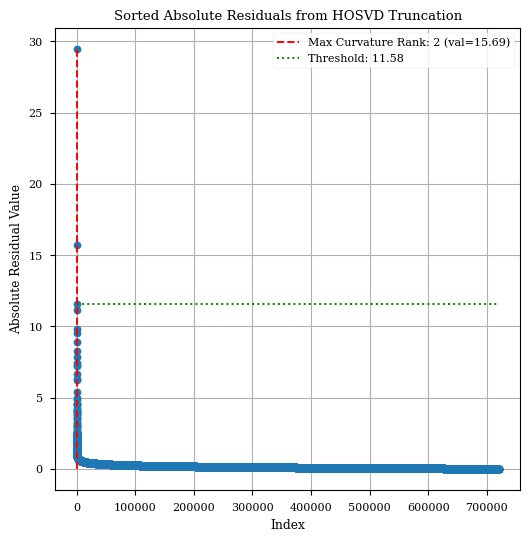

In [50]:

core_dim = rank_estimates['R2']['estimated_ranks']
P = rank_estimates['R2']['num_param']
print(f"Using core dimensions: {core_dim}, # params: {P}")
hosvd_decomp = hosvd(Y, core_dims=core_dim)
truncated_Y = hosvd_decomp['core']
for i, mode in enumerate([1, 2, 3, 4]):
    truncated_Y = mode_product(truncated_Y, hosvd_decomp['factors'][i], mode)

residual_Y = Y - truncated_Y.cpu().numpy()

abs_res_Y = np.abs(residual_Y).ravel()
abs_res_Y = np.sort(abs_res_Y)[::-1]
fig, axe = plt.subplots(1,1, figsize=(6,6))

axe.plot(abs_res_Y, marker='o', linestyle='None')
# plt.yscale('log')
axe.set_xlabel('Index')
axe.set_ylabel('Absolute Residual Value')
axe.set_title('Sorted Absolute Residuals from HOSVD Truncation')
axe.grid(True)

rank, idx = max_curvature_rank(abs_res_Y, smooth_window=3, logscale=False)
# rank, idx = kneedle_elbow(abs_res_Y, decreasing=True)
axe.vlines(rank, ymin=0, ymax=abs_res_Y[0],
            colors='red', linestyles='dashed',
            label=f'Max Curvature Rank: {rank} (val={abs_res_Y[idx]:.2f})')
threshold = abs_res_Y[idx+1] if idx+1 < len(abs_res_Y) else 0.0
axe.hlines(threshold, xmin=0, xmax=len(abs_res_Y),
            colors='green', linestyles='dotted',
            label=f'Threshold: {threshold:.2f}')
axe.legend()

{'GCV': {'dispersion_estimate_MAD': np.float64(0.022939324281329335),
         'estimated_ranks': [46, 52, 7, 24],
         'num_detected_events': [0, 2, 2, 4, 5, 5, 6, 6],
         'num_param': 403518.0,
         'r2_value': 0.9933558622176799,
         'ratios': [0.00014, 0.0007, 0.0014, 0.003, 0.007, 0.01, 0.02, 0.03],
         'residual_energy': 2138.7502360602375,
         'total_detected_events': 30,
         'total_detected_support_ratio': [0.0,
                                          0.045454545454545456,
                                          0.045454545454545456,
                                          0.06060606060606061,
                                          0.06818181818181818,
                                          0.09848484848484848,
                                          0.15151515151515152,
                                          0.17424242424242425],
         'variance_estimate': np.float64(0.001274766873878197)},
 'R2': {'dispersion_estimate_MAD':

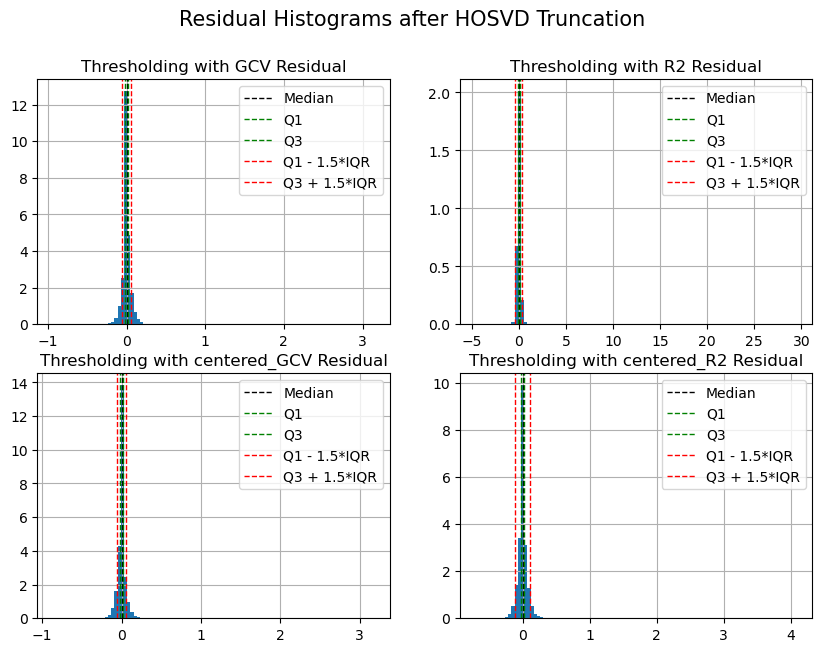

: 

In [19]:
# nyc_taxi = NYCTaxiDataset()
# Y = nyc_taxi.dropoffs
Y = scaled_Y
D = np.prod(Y.shape)
methods = ['GCV', 'R2', 'centered_GCV', 'centered_R2']

fig, axes = plt.subplots(ncols=2, nrows=2, figsize=(10, 7))
axes = axes.flatten()
for k, method in enumerate(methods):
    # Y = nyc_taxi.dropoffs
    core_dim = rank_estimates[method]['estimated_ranks']
    P = rank_estimates[method]['num_param']
    if method.startswith('centered'):
        Y = Y - np.mean(Y, axis=(1, 2), keepdims=True)
    
    hosvd_decomp = hosvd(Y, core_dims=core_dim)
    truncated_Y = hosvd_decomp['core']
    for i, mode in enumerate([1, 2, 3, 4]):
        truncated_Y = mode_product(truncated_Y, hosvd_decomp['factors'][i], mode)
    
    residual_Y = Y - truncated_Y.cpu().numpy()
    median_res = np.median(residual_Y.ravel())
    Q1 = np.quantile(residual_Y.ravel(), 0.25)
    Q3 = np.quantile(residual_Y.ravel(), 0.75)
    IQR = Q3 - Q1
    outlier_labels = (residual_Y < Q1 - 1.5 * IQR) | (residual_Y > Q3 + 1.5 * IQR)
    non_outliers = residual_Y[~outlier_labels]

    axes[k].set_title('Thresholding with ' + method +' Residual')
    axes[k].hist(residual_Y.ravel(), bins=100, density=True)
    axes[k].axvline(median_res, color='k', linestyle='dashed', linewidth=1, label='Median')
    axes[k].axvline(Q1, color='g', linestyle='dashed', linewidth=1, label='Q1')
    axes[k].axvline(Q3, color='g', linestyle='dashed', linewidth=1, label='Q3')
    axes[k].axvline(Q1-1.5*IQR, color='r', linestyle='dashed', linewidth=1, label='Q1 - 1.5*IQR')
    axes[k].axvline(Q3+1.5*IQR, color='r', linestyle='dashed', linewidth=1, label='Q3 + 1.5*IQR')
    axes[k].grid(True)
    axes[k].legend()

    scoring_results = nyc_taxi.anomaly_scoring_score(np.abs(residual_Y))
    scoring_results.pop('detected_events')
    detection_results = nyc_taxi.anomaly_detection_score(outlier_labels)
    detection_results = {
        # 'detected_events': detection_results['detected_events'],
        'num_detected_events': detection_results['num_detected_events'],
        'total_detected_support_ratio': detection_results['total_detected_support_ratio'],
    }
    rank_estimates[method].update(detection_results)
    rank_estimates[method].update(scoring_results)
    variance_est = np.var(non_outliers)
    variance_est_corrected = variance_est * (D/(D - P))
    rank_estimates[method]['variance_estimate'] = variance_est_corrected
    rank_estimates[method]['dispersion_estimate_MAD'] = np.median(np.abs(residual_Y), axis=(0,1,2,3))/0.6745
    # rank_estimates[method]['spatial_dispersion_estimate_MAD'] = np.median(np.abs(residual_Y), axis=(1,2,3))/0.6745
fig.suptitle('Residual Histograms after HOSVD Truncation', fontsize=15)
pprint(rank_estimates)

### Save the rank and variance estimates for NYC Taxi Dataset

In [ ]:
methods = ['GCV', 'R2', 'centered_GCV', 'centered_R2']
columns = ['estimated_ranks', 'num_param', 'r2_value', 'residual_energy', 'num_detected_events', 'variance_estimate', 'detected_triggered_ratio', 'total_triggered_ratio']
dfds = []
for method in methods:
    dfds.append({k: v for k, v in rank_estimates[method].items() if k in columns})
    dfds[-1].update({'Method': method})
    
dfnyc = pd.DataFrame(dfds, columns=columns+ ['Method'])
dfnyc = dfnyc.set_index('Method')
dfnyc.to_csv(BASE_DIR / 'experiment_board' / 'smd_anomaly_detection' / 'results'/ 'nyc_taxi_rank_and_variance_estimates.csv')

### Apply Grouped Outlier Robust Higher-order PCA Models for Event Detection on NYC Taxi Dataset

In [ ]:
# import optuna
from src.models.lr_ssd.snn__logn_gtv import SNN__LOGN_GTV
nx.config.warnings_to_ignore.add("cache")

nyc_taxi = NYCTaxiDataset(edge_weighting={
    'method': 'rbf',
    'c': 0.005}
    )

model_keys = ['HoRPCA',
            'SNN_LOGNTE',
            'SNN_LOGN', 
            'SNN_LOGNST',
            'SNN_L1_GTV_T',
            'SNN_L1_GTVS_sn',
            'SNN_LOGN_SN_GTV_T',
            "SNN_LOGN_SN_GTV_S",
            'SNN_LOGNST_GTVST',
            ]
with open(CFG_DIR / 'model_configs.yaml') as f:
    model_configs = yaml.safe_load(f)
model_names = [ model_configs[key]['name'] for key in model_keys]

results = defaultdict(dict)
print(f"Model: {'':<30} # Detected Anomalies:")
print("-"*80)
for i, model_key in enumerate(model_keys):
    model_config = model_configs[model_key]
    model_select = { # Model selection based on the model_config
                'graph': model_config['graph'],
                'lr_modes': model_config['lr_modes'],
                'graph_modes': model_config['graph_modes'],
                'grouping': model_config['grouping'],
                'weighing': 'size_normalized',#'uniform', #'size_normalized_inv', #, #,#'uniform',#'uniform',#model_config['weighing'],
                'r_hop': model_config['r_hop'],
                'soft_constrained': model_config.get('soft_constrained', False),
                'device': model_config.get('device', 'cuda' if torch.cuda.is_available() else 'cpu'),
                'dtype': model_config.get('dtype', torch.float64),
                'verbose': 0,
                'gtvr_config': model_config['gtvr_config'],
                }
    model_run = {
                'max_iter': 500,#5000,
                'rho': model_config.get('rho', 0.03),
                'err_tol': model_config.get('err_tol', 1e-4),
                'rho_update': model_config.get('rho_update', 'domain_parametrization'),
                'rho_update_thr': model_config.get('rho_update_thr', 100)
        }

    if model_select['graph'] == 'temporal':
        G = nyc_taxi.Gt
    elif model_select['graph'] == 'spatial':
        G = nyc_taxi.G
    elif model_select['graph'] == 'spatio-temporal':
        G = nx.cartesian_product(nyc_taxi.G, nyc_taxi.Gt)
    else:
        raise ValueError(f"Unknown graph type: {model_select['graph']}")

    
    model = SNN__LOGN_GTV(scaled_Y,G, **model_select)
    group_sizes = model.expander.to_dense().sum(axis=1)
    group_size_arithmetic_mean = group_sizes.mean().item()
    
    lda = 1/(group_size_arithmetic_mean*(81)**0.5)
                
    for g, gtv_regularization in enumerate(model_config['gtvr_config']):
        modes = gtv_regularization['mode']
        dims = [Y.shape[m-1] for m in modes]
        num_gtv_vertices = np.prod(dims)
                # sqrt(Estimated variance) * sqrt(2*log(number_of_variates_to_penalize))
                # This is based on the paper "Atomic Decomposition by Basis Pursuit"
    lda_gtvs = [np.sqrt(0.0229)*np.sqrt(2*np.log(num_gtv_vertices))
                for g in range(len(model_config['gtvr_config']))]
    
    
    X, S = model([n/min(nn_angle_weights) for n in nn_angle_weights],#nn_angle_weights,
                lda,
                lda_gtvs,
                **model_run)
    
    scores = np.abs(model.S.cpu().numpy())
    scores = scores/scales
    normal_part = model.X
    model_result = nyc_taxi.anomaly_scoring_score(scores)
    results[model_key] = model_result
    model_name = model_configs[model_key]['name'].replace('[SNN]-', '').replace('_sn', '')
    print(f"{model_name:<30} {model_result['num_detected_events']}")

    # S = nyc_taxi.Y
    # ocsvm_scores = np.zeros_like(S)
    # for l in range(81):
    #     for d in range(7):
    #         for h in range(24):
    #             s = S[l,:,d,h]
    #             s = s.reshape(-1, 1)
    #             features = s
    #             # x = X[l,:,d,h]
    #             # x = x.reshape(-1, 1)
    #             # features = np.concatenate((s,x), axis=1)
    #             clf = OneClassSVM(gamma='scale',
    #                             kernel='rbf',
    #                             verbose=0).fit(features)
    #             ldh_scores = clf.score_samples(features)
    #             ocsvm_scores[l,:,d,h] = ldh_scores.ravel()
    # ocsvm_scores = -ocsvm_scores
    # print(f"{model_name+'-OCSVM':<30} {model_result['num_detected_events']}")

Model:                                # Detected Anomalies:
--------------------------------------------------------------------------------
HoRPCA                         [2, 4, 6, 6, 7, 7, 8, 8]
[LOGN(T-E)]                    [2, 6, 8, 13, 14, 14, 16, 16]
[LOGN(S-N)]                    [2, 5, 8, 11, 17, 17, 17, 18]
[LOGN(ST-N)]                   [1, 6, 6, 9, 12, 12, 16, 17]
[L1+GTV(T)]                    [1, 3, 3, 3, 4, 5, 9, 14]
[L1+GTV(S)]                    [3, 6, 6, 6, 7, 9, 10, 11]
[LOGN(S-N)+GTV(T)]             [2, 2, 2, 2, 3, 4, 6, 8]
[LOGN(S-N)+GTV(S)]             [3, 6, 9, 12, 15, 16, 18, 19]
[LOGN(ST-N)+GTV(ST)]           [0, 1, 1, 2, 2, 2, 2, 2]


In [ ]:
# from sklearn.manifold import spectral_embedding
from sklearn.svm import OneClassSVM
# from sklearn.linear_model import SGDOneClassSVM

# s = matricize(model.S.cpu().numpy(), [1,2])
# S = model.S.cpu().numpy()
# X = model.X.cpu().numpy()
# S = scaled_Y
S = nyc_taxi.Y
ocsvm_scores = np.zeros_like(S)
for l in tqdm(range(81), total=81, desc="Fitting One-Class SVMs"):
    for d in range(7):
        for h in range(24):
            s = S[l,:,d,h]
            s = s.reshape(-1, 1)
            features = s
            # x = X[l,:,d,h]
            # x = x.reshape(-1, 1)
            # features = np.concatenate((s,x), axis=1)
            clf = OneClassSVM(gamma='scale',
                              kernel='rbf',
                              verbose=0).fit(features)
            ldh_scores = clf.score_samples(features)
            ocsvm_scores[l,:,d,h] = ldh_scores.ravel()

nyc_taxi.anomaly_scoring_score(-ocsvm_scores)

Fitting One-Class SVMs: 100%|██████████| 81/81 [00:04<00:00, 16.42it/s]


defaultdict(list,
            {'ratios': [0.00014,
              0.0007,
              0.0014,
              0.003,
              0.007,
              0.01,
              0.02,
              0.03],
             'num_detected_events': [0, 0, 2, 2, 7, 9, 11, 14],
             'detected_events': [[0,
               0,
               0,
               0,
               0,
               0,
               0,
               0,
               0,
               0,
               0,
               0,
               0,
               0,
               0,
               0,
               0,
               0,
               0,
               0],
              [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
              [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1],
              [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1],
              [1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1],
              [1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 

: 

### Apply the Models on Server Machine Dataset for Anomaly Detection

In [12]:
import optuna
# HoRPCA,SNN_LOGNTE,SNN_LOGN,SNN_L1_GTV_T,SNN_LOGNST,SNN_L1_GTVS,SNN_LOGN_SN_GTV_T
model_keys = ['HoRPCA','SNN_LOGNTE','SNN_L1_GTV_T', 'SNN_LOGN_SN_GTV_T', 'SNN_LOGN', 'SNN_LOGNST','SNN_L1_GTVS']
# model_keys = ['HoRPCA-f','SNN_LOGNTE_F','SNN_L1_GTV_T_F', 'SNN_LOGN_SN_GTV_T_F',
#              'SNN_LOGN_F', 'SNN_LOGNST_F','SNN_L1_GTVS_F']
with open(CFG_DIR / 'model_configs.yaml') as f:
    model_configs = yaml.safe_load(f)

model_names = [ model_configs[key]['name'] for key in model_keys]


machine_id = 0
channel_id = 9
num_channels = {1:8, 2: 9, 3: 11}
# metric_name = 'rbf_abs_S_score_gic_3_nyc_constrained'#'gic_1_nyc_constrained'#'gic_1_two_phase'
metric_name = 'rbf_abs_S_score_gic_3_nyc_constrained'

filter_query = 'non_zero_S_ratio >= 0.02 and non_zero_S_ratio <= 0.15'
optimization_metric = 'gcv'
minimization_metric = True # Set to true if minimized
attributes_of_interest = ['gic_3',
                            'scoring_num_detected_events',
                            'scoring_total_detected_support_ratio',
                            'non_zero_S_ratio',
                            'dof_S',
                            'dof_X',
                            'loss',
                            'nll',
                            'X_t_rank']
results = defaultdict(dict)

for m, model_name in enumerate(model_names):
    study_name = model_name + f"_m{machine_id}_ch{channel_id}" + f"_scfg{metric_name}"
    storage = f'sqlite:///{RESULTS_DIR.absolute()}/{model_keys[m]}_m{machine_id}_ch{channel_id}.db'

    study = optuna.create_study(study_name=study_name,
                                storage=storage,
                                load_if_exists=True,
                                direction='minimize')

    results[model_name]['study'] = study
    # results[model_name]['params'] = study.best_trial.params
    study_df = study.trials_dataframe()
    if study_df.empty:
        continue
    
    study_df= study_df.rename(columns=lambda x: x.replace('user_attrs_', '')
                    ).rename(columns=lambda x: x.replace('params_', '')
                    ).rename(columns=lambda x: x.replace('raw_', ''))
    

    study_df = study_df.sort_values(by=optimization_metric,
                                    ascending=minimization_metric)

    filtered_study_df = study_df.query(filter_query)
    if not filtered_study_df.empty:
        study_df = filtered_study_df
    else:
        print(f"Warning: No trials passed the filter for {model_name}. Using unfiltered results.")
    best_trial = study_df.iloc[0]

    for attr in attributes_of_interest:
        results[model_name][attr] = best_trial[attr]

pprint(results)

[I 2025-09-25 18:04:09,648] Using an existing study with name 'HoRPCA_m0_ch9_scfgrbf_abs_S_score_gic_3_nyc_constrained' instead of creating a new one.
[I 2025-09-25 18:04:10,233] Using an existing study with name '[SNN]-[LOGN(T-E)]_m0_ch9_scfgrbf_abs_S_score_gic_3_nyc_constrained' instead of creating a new one.
[I 2025-09-25 18:04:10,603] Using an existing study with name '[SNN]-[L1+GTV(T)]_m0_ch9_scfgrbf_abs_S_score_gic_3_nyc_constrained' instead of creating a new one.
[I 2025-09-25 18:04:10,972] Using an existing study with name '[SNN]-[LOGN(S-N)+GTV(T)]_m0_ch9_scfgrbf_abs_S_score_gic_3_nyc_constrained' instead of creating a new one.
[I 2025-09-25 18:04:11,152] Using an existing study with name '[SNN]-[LOGN(S-N)]_m0_ch9_scfgrbf_abs_S_score_gic_3_nyc_constrained' instead of creating a new one.
[I 2025-09-25 18:04:11,834] Using an existing study with name '[SNN]-[LOGN(ST-N)]_m0_ch9_scfgrbf_abs_S_score_gic_3_nyc_constrained' instead of creating a new one.
[I 2025-09-25 18:04:12,540] Usi

defaultdict(<class 'dict'>,
            {'HoRPCA': {'X_t_rank': [37, 52, 7, 20],
                        'dof_S': np.int64(21987),
                        'dof_X': np.float64(271120.0),
                        'gic_3': np.float64(650037894.4734486),
                        'loss': np.float64(0.0017308027080772058),
                        'nll': np.float64(3.099713749871084),
                        'non_zero_S_ratio': np.float64(0.030485674353598884),
                        'scoring_num_detected_events': [1,
                                                        3,
                                                        5,
                                                        10,
                                                        14,
                                                        15,
                                                        17,
                                                        17],
                        'scoring_total_detected_support_ratio': [

: 

In [3]:
import numpy as np
from scipy.stats import norm

def fdr_bh_from_zscores(z_scores, q=0.05, two_sided=True):
    """
    Benjamini-Hochberg FDR control for anomaly detection from Z-scores.

    Parameters
    ----------
    z_scores : np.ndarray
        1D or ND array of Z-scores.
    q : float
        Desired false discovery rate (e.g. 0.05).
    two_sided : bool
        Whether to compute two-sided p-values (default True).

    Returns
    -------
    mask : np.ndarray of bool
        Boolean array (same shape as z_scores), True if entry is declared significant.
    """
    # flatten input
    z = np.ravel(z_scores)

    # p-values
    if two_sided:
        p = 2 * (1 - norm.cdf(np.abs(z)))
    else:
        p = 1 - norm.cdf(z)   # one-sided

    N = len(p)
    # sort p-values
    idx_sorted = np.argsort(p)
    p_sorted = p[idx_sorted]

    # BH critical values
    crit = (np.arange(1, N+1) / N) * q

    # find largest k where p_(k) <= crit_(k)
    below = p_sorted <= crit
    if not np.any(below):
        # no discoveries
        mask = np.zeros_like(z, dtype=bool)
    else:
        k = np.max(np.where(below)[0])  # last index that passes
        threshold = p_sorted[k]
        mask = p <= threshold

    return mask.reshape(z_scores.shape)

In [8]:
# import optuna
from src.models.lr_ssd.snn__logn_gtv import SNN__LOGN_GTV
from sklearn.svm import OneClassSVM
# from sklearn.linear_model import SGDOneClassSVM as OneClassSVM
nx.config.warnings_to_ignore.add("cache")

from sklearn.mixture import GaussianMixture



# model_keys = ['HoRPCA','SNN_LOGNTE','SNN_L1_GTV_T', 'SNN_LOGN_SN_GTV_T', 'SNN_LOGN', 'SNN_LOGNST','SNN_L1_GTVS']
model_keys = ['HoRPCA',
            'SNN_LOGNTE',
            'SNN_LOGN', 
            'SNN_LOGNST',
            'SNN_L1_GTV_T',
            'SNN_L1_GTVS_sn',
            'SNN_LOGN_SN_GTV_T',
            "SNN_LOGN_SN_GTV_S",
            'SNN_LOGNST_GTVST',
            ]

variance_estimates = pd.read_csv(RESULTS_DIR / 'rank_and_variance_estimates.csv', index_col=[0,1,2]
                                    ).loc['R2']['variance_estimate'].to_dict()
with open(CFG_DIR / 'model_configs.yaml') as f:
    model_configs = yaml.safe_load(f)
model_names = [ model_configs[key]['name'] for key in model_keys]


def run_model_on_ch(model_key, machine_id, channel_id,
                        use_post_ocsvm=False, k=3):
    data = SMDMachineChannel(machine_id=machine_id,channel_id=channel_id,
                            edge_weighting={
                                'method': 'rbf',
                                'c': 0.005}
                            )
    variance_estimate = variance_estimates[(machine_id, channel_id)]
    model_config = model_configs[model_key]
    model_select = { # Model selection based on the model_config
                'graph': model_config['graph'],
                'lr_modes': model_config['lr_modes'],
                'graph_modes': model_config['graph_modes'],
                'grouping': model_config['grouping'],
                'weighing': 'size_normalized',#'uniform', #'size_normalized_inv', #, #,#'uniform',#'uniform',#model_config['weighing'],
                'r_hop': model_config['r_hop'],
                'soft_constrained': model_config.get('soft_constrained', False),
                'device': model_config.get('device', 'cuda' if torch.cuda.is_available() else 'cpu'),
                'dtype': model_config.get('dtype', torch.float64),
                'verbose': 0,
                'gtvr_config': model_config['gtvr_config'],
                }
    model_run = {
                'max_iter': 300,#5000,
                'rho': model_config.get('rho', 0.03),
                'err_tol': model_config.get('err_tol', 1e-4),
                'rho_update': model_config.get('rho_update', 'domain_parametrization'),
                'rho_update_thr': model_config.get('rho_update_thr', 100)
        }

    if model_select['graph'] == 'temporal':
        G = data.Gt
    elif model_select['graph'] == 'spatial':
        G = data.G
    elif model_select['graph'] == 'spatio-temporal':
        G = nx.cartesian_product(data.G, data.Gt)
    else:
        raise ValueError(f"Unknown graph type: {model_select['graph']}")

    Y = data.Y
    hosvd_decomp = hosvd(Y)
    svals = hosvd_decomp['svals']
    nuc_norms = []
    concentration_weights = []
    angle_weights_with_dim = []
    for j in range(4):
        mode_svals = svals[j].cpu().numpy()
        full_rank_svals = np.ones(svals[j].shape)/len(svals[j])
        nuc_norms.append(torch.sum(svals[j]).item())
        sval_cosine_dist = 1 - np.dot(mode_svals, full_rank_svals
                                )/(np.linalg.norm(mode_svals)*np.linalg.norm(full_rank_svals))
        concentration_weights.append(sval_cosine_dist.item())
        angle_weights_with_dim.append(sval_cosine_dist.item() * np.sqrt(Y.shape[j]).item())
    nn_angle_weights = [n/min(concentration_weights) for n in concentration_weights]
    
    model = SNN__LOGN_GTV(Y,G, **model_select)
    group_sizes = model.expander.to_dense().sum(axis=1)
    group_size_arithmetic_mean = group_sizes.mean().item()
    # Hyper-parameter settings
    
    lda = 1/(group_size_arithmetic_mean*(60)**0.5)
    
    for g, gtv_regularization in enumerate(model_config['gtvr_config']):
        modes = gtv_regularization['mode']
        dims = [Y.shape[m-1] for m in modes]
        num_gtv_vertices = np.prod(dims)
                # sqrt(Estimated variance) * sqrt(2*log(number_of_variates_to_penalize))
                # This is based on the paper "Atomic Decomposition by Basis Pursuit"
    lda_gtvs = [np.sqrt(variance_estimate)*np.sqrt(2*np.log(num_gtv_vertices))
                for g in range(len(model_config['gtvr_config']))]
    
    X, S = model(nn_angle_weights,
                lda,
                lda_gtvs,
                **model_run)
    

    scores = model.S.abs()
    std = model.S.std()
    # t_labels = scores > lda*k

    # model.V
    
    # t_labels = scores > (std_MAD * (2 * np.log(np.prod(S.shape)))**0.5)
    
    # z_scores = (scores/std).cpu().numpy()
    # t_labels = fdr_bh_from_zscores(z_scores, q=0.01, two_sided=False)
    # t_labels = np.zeros(scores.shape, dtype=bool)
    # scores = scores.cpu().numpy()
    # gm = GaussianMixture(n_components=2, random_state=0)
    # labels = gm.fit_predict(scores.ravel().reshape(-1, 1))
    # t_labels = (labels == np.argmax(gm.means_)).reshape(scores.shape)
    # for i in range(scores.shape[0]):
    #     for j in range(scores.shape[1]):
    #         gm = GaussianMixture(n_components=2, random_state=0)
    #         labels = gm.fit_predict(scores[i,j,...].ravel().reshape(-1, 1))
    #         t_labels[i,j,...] = (labels == np.argmax(gm.means_)).reshape(scores.shape[2:])
    # t_labels = (scores > model.w.mean()*lda*k).cpu().numpy()
    # t_labels = (scores > group_size_arithmetic_mean*lda*k).cpu().numpy()
    group_magnitudes = ((model.V**2).sum(dim=1, keepdims=True).coalesce()**0.5).to_dense()
    thresholded_groups = (group_magnitudes > model.w*group_size_arithmetic_mean*lda*k)
    thresholded_groups = model.expander * thresholded_groups
    thresholded_entries = (thresholded_groups.sum(dim=0)).to_dense().squeeze()>0
    t_labels = tensorize(thresholded_entries, model.Y.shape, model.graph_modes).cpu().numpy().astype(bool)

    scoring_score = data.anomaly_scoring_score(scores)
    detection_score = data.anomaly_detection_score(t_labels)
    scoring_score.pop('st_scores', None)
    scoring_score.pop('t_scores', None)
    results = {**scoring_score, **detection_score}
    if use_post_ocsvm:
        scores = np.zeros_like(model.S.cpu().numpy())
        Snpy = S.cpu().numpy()
        t_labels = np.zeros_like(Snpy, dtype=bool)
        for l in range(Y.shape[0]):
            for d in range(Y.shape[1]):
                for h in range(Y.shape[3]):
                    s = Snpy[l,d, :, h].reshape(-1, 1)
                    clf = OneClassSVM(gamma='scale',
                                    kernel='rbf',
                                    nu=0.01,
                                    verbose=0).fit(s)
                    ld_scores = clf.score_samples(s)
                    ld_labels = clf.predict(s).ravel()
                    scores[l,d,:,h] = ld_scores.reshape(Snpy.shape[2])
                    t_labels[l,d,:,h] = ld_labels.reshape(Snpy.shape[2])
        scores = scores
        
        t_labels = (t_labels == 1)
        ocsvm_scoring_score = data.anomaly_scoring_score(scores) 
        ocsvm_detection_score = data.anomaly_detection_score(t_labels)
        ocsvm_scoring_score.pop('st_scores', None)
        ocsvm_scoring_score.pop('t_scores', None)
        ocsvm_results = {**ocsvm_scoring_score, **ocsvm_detection_score}
        return results, ocsvm_results
    return results

In [38]:
results = defaultdict(dict)
model_keys = ['HoRPCA',
            # 'SNN_L1_GTV_T',
            # 'SNN_L1_GTVS_sn',
            'SNN_LOGNTE',
            'SNN_LOGN', 
            'SNN_LOGNST',
            'SNN_LOGN_SN_GTV_T',
            "SNN_LOGN_SN_GTV_S",
            'SNN_LOGNST_GTVST',
            ]
machines = [1, 2, 3]
num_channels = {1:8, 2: 9, 3: 11}
start_col = 30

for machine_id in machines:
    for channel_id in range(1, num_channels[machine_id]+1):
        print(f"\nMachine {machine_id}, Channel {channel_id}:")
        for m, model_key in enumerate(model_keys):
            # model_result, ocsvm_result = run_model_on_ch(model_key, machine_id, channel_id,
            #                                 use_post_ocsvm=True)
            model_result = run_model_on_ch(model_key, machine_id, channel_id,
                                            use_post_ocsvm=False, k=1.0)
            
            results[model_key][(machine_id, channel_id)] = model_result
            model_name = model_configs[model_key]['name'].replace('[SNN]-', '').replace('_sn','')
            print((f"Model: {model_name:<30}AU-ROC={model_result['au_roc']:>7.3f}\t"
                    f" AU-PRC={model_result['au_prc']:>7.3f}\t"
                    f" F1={model_result['f1']:>7.3f}\t Precision={model_result['precision']:>7.3f}\t Recall={model_result['recall']:>7.3f}\t"
                    f" PA-F1={model_result['PA_F1']:>7.3f}\t PA-Precision={model_result['PA_precision']:>7.3f}\t PA-Recall={model_result['PA_recall']:>7.3f}"))
            
            # results[model_key+'_OCSVM'][(machine_id, channel_id)] = ocsvm_result
            # model_name = model_configs[model_key]['name'].replace('[SNN]-', '').replace('_sn','')+'-OCSVM'
            # print((f"Model: {model_name:<30}AU-ROC={ocsvm_result['au_roc']:>7.3f}\t"
            #         f" AU-PRC={ocsvm_result['au_prc']:>7.3f}\t"
            #         f" F1={ocsvm_result['f1']:>7.3f}\t Precision={ocsvm_result['precision']:>7.3f}\t Recall={ocsvm_result['recall']:>7.3f}\t"
            #         f" PA-F1={ocsvm_result['PA_F1']:>7.3f}\t PA-Precision={ocsvm_result['PA_precision']:>7.3f}\t PA-Recall={ocsvm_result['PA_recall']:>7.3f}"))


Machine 1, Channel 1:
Model: HoRPCA                        AU-ROC=  0.682	 AU-PRC=  0.250	 F1=  0.120	 Precision=  0.598	 Recall=  0.067	 PA-F1=  0.973	 PA-Precision=  0.957	 PA-Recall=  0.990
Model: [LOGN(T-E)]                   AU-ROC=  0.839	 AU-PRC=  0.425	 F1=  0.275	 Precision=  0.426	 Recall=  0.203	 PA-F1=  0.875	 PA-Precision=  0.783	 PA-Recall=  0.991
Model: [LOGN(S-N)]                   AU-ROC=  0.820	 AU-PRC=  0.419	 F1=  0.196	 Precision=  0.512	 Recall=  0.121	 PA-F1=  0.941	 PA-Precision=  0.895	 PA-Recall=  0.992
Model: [LOGN(ST-N)]                  AU-ROC=  0.908	 AU-PRC=  0.593	 F1=  0.524	 Precision=  0.435	 Recall=  0.658	 PA-F1=  0.698	 PA-Precision=  0.538	 PA-Recall=  0.996
Model: [LOGN(S-N)+GTV(T)]            AU-ROC=  0.735	 AU-PRC=  0.368	 F1=  0.194	 Precision=  0.597	 Recall=  0.116	 PA-F1=  0.958	 PA-Precision=  0.927	 PA-Recall=  0.991
Model: [LOGN(S-N)+GTV(S)]            AU-ROC=  0.807	 AU-PRC=  0.404	 F1=  0.192	 Precision=  0.598	 Recall=  0.115	 PA-F1=

In [5]:
results = defaultdict(dict)
model_keys = ['HoRPCA',
            'SNN_L1_GTV_T',
            'SNN_L1_GTVS_sn',
            'SNN_LOGNTE',
            'SNN_LOGN', 
            'SNN_LOGNST',
            'SNN_LOGN_SN_GTV_T',
            "SNN_LOGN_SN_GTV_S",
            'SNN_LOGNST_GTVST',
            ]
machines = [1, 2, 3]
num_channels = {1:8, 2: 9, 3: 11}
start_col = 30

for machine_id in machines:
    for channel_id in range(1, num_channels[machine_id]+1):
        print(f"\nMachine {machine_id}, Channel {channel_id}:")
        for m, model_key in enumerate(model_keys):
            model_result, ocsvm_result = run_model_on_ch(model_key, machine_id, channel_id,
                                            use_post_ocsvm=True)
            
            results[model_key][(machine_id, channel_id)] = model_result
            model_name = model_configs[model_key]['name'].replace('[SNN]-', '').replace('_sn','')
            print((f"Model: {model_name:<30}AU-ROC={model_result['au_roc']:>7.3f}\t"
                    f" AU-PRC={model_result['au_prc']:>7.3f}\t"
                    f" F1={model_result['f1']:>7.3f}\t Precision={model_result['precision']:>7.3f}\t Recall={model_result['recall']:>7.3f}\t"
                    f" PA-F1={model_result['PA_F1']:>7.3f}\t PA-Precision={model_result['PA_precision']:>7.3f}\t PA-Recall={model_result['PA_recall']:>7.3f}"))
            
            results[model_key+'_OCSVM'][(machine_id, channel_id)] = ocsvm_result
            model_name = model_configs[model_key]['name'].replace('[SNN]-', '').replace('_sn','')+'-OCSVM'
            print((f"Model: {model_name:<30}AU-ROC={ocsvm_result['au_roc']:>7.3f}\t"
                    f" AU-PRC={ocsvm_result['au_prc']:>7.3f}\t"
                    f" F1={ocsvm_result['f1']:>7.3f}\t Precision={ocsvm_result['precision']:>7.3f}\t Recall={ocsvm_result['recall']:>7.3f}\t"
                    f" PA-F1={ocsvm_result['PA_F1']:>7.3f}\t PA-Precision={ocsvm_result['PA_precision']:>7.3f}\t PA-Recall={ocsvm_result['PA_recall']:>7.3f}"))


Machine 1, Channel 1:


/mnt/ffs24/home/indibimu/repos/ML_GSP/src/proximal_ops/prox_overlapping_grouped_l21.py:396: UserWarning: Sparse CSR tensor support is in beta state. If you miss a functionality in the sparse tensor support, please submit a feature request to https://github.com/pytorch/pytorch/issues. (Triggered internally at /pytorch/aten/src/ATen/SparseCsrTensorImpl.cpp:53.)
  G_ind = torch.sparse.spdiags(diagonals= torch.ones(G.number_of_nodes(), device=device, dtype=dtype),


Model: HoRPCA                        AU-ROC=  0.682	 AU-PRC=  0.250	 F1=  0.218	 Precision=  0.318	 Recall=  0.166	 PA-F1=  0.845	 PA-Precision=  0.736	 PA-Recall=  0.992
Model: HoRPCA-OCSVM                  AU-ROC=  0.749	 AU-PRC=  0.284	 F1=  0.173	 Precision=  0.095	 Recall=  1.000	 PA-F1=  0.173	 PA-Precision=  0.095	 PA-Recall=  1.000
Model: [L1+GTV(T)]                   AU-ROC=  0.666	 AU-PRC=  0.245	 F1=  0.177	 Precision=  0.390	 Recall=  0.115	 PA-F1=  0.913	 PA-Precision=  0.847	 PA-Recall=  0.991
Model: [L1+GTV(T)]-OCSVM             AU-ROC=  0.632	 AU-PRC=  0.236	 F1=  0.173	 Precision=  0.095	 Recall=  1.000	 PA-F1=  0.173	 PA-Precision=  0.095	 PA-Recall=  1.000
Model: [L1+GTV(S)]                   AU-ROC=  0.740	 AU-PRC=  0.268	 F1=  0.207	 Precision=  0.304	 Recall=  0.157	 PA-F1=  0.844	 PA-Precision=  0.734	 PA-Recall=  0.992
Model: [L1+GTV(S)]-OCSVM             AU-ROC=  0.752	 AU-PRC=  0.288	 F1=  0.173	 Precision=  0.095	 Recall=  1.000	 PA-F1=  0.173	 PA-Precision= 

Machine 1, Channel 1:
Model: HoRPCA                        AU-ROC=  0.682	 AU-PRC=  0.250	 F1=  0.188	 Precision=  0.319	 Recall=  0.133	 PA-F1=  0.871	 PA-Precision=  0.777	 PA-Recall=  0.992 Threshold=  0.082	 Threshold_MAD=  0.054	 Std(S)_MAD=  0.010	 Std(S)_naive=  0.010
Model: HoRPCA-OCSVM                  AU-ROC=  0.749	 AU-PRC=  0.284	 F1=  0.173	 Precision=  0.095	 Recall=  1.000	 PA-F1=  0.173	 PA-Precision=  0.095	 PA-Recall=  1.000
**8*std Results**
Machine 1, Channel 1:
Model: HoRPCA                        AU-ROC=  0.682	 AU-PRC=  0.250	 F1=  0.163	 Precision=  0.405	 Recall=  0.102	 PA-F1=  0.926	 PA-Precision=  0.869	 PA-Recall=  0.991
Model: HoRPCA-OCSVM                  AU-ROC=  0.749	 AU-PRC=  0.284	 F1=  0.173	 Precision=  0.095	 Recall=  1.000	 PA-F1=  0.173	 PA-Precision=  0.095	 PA-Recall=  1.000

In [18]:
# from sklearn.manifold import spectral_embedding
from sklearn.svm import OneClassSVM
# from sklearn.linear_model import SGDOneClassSVM
machines = [1, 2, 3]
num_channels = {1:8, 2: 9, 3: 11}
def run_ocsvm_on_ch(machine_id, channel_id):
    data = SMDMachineChannel(machine_id=machine_id,channel_id=channel_id)
    S = data.Y
    ocsvm_scores = np.zeros_like(S)
    ocsvm_labels = np.zeros_like(S, dtype=bool)
    for l in range(data.Y.shape[0]):
        for d in range(data.Y.shape[2]):
            for h in range(data.Y.shape[3]):
                s = S[l,:,d,h]
                s = s.reshape(-1, 1)
                features = s
                # x = X[l,:,d,h]
                # x = x.reshape(-1, 1)
                # features = np.concatenate((s,x), axis=1)
                clf = OneClassSVM(gamma='scale',
                                kernel='rbf',
                                verbose=0).fit(features)
                ldh_scores = clf.score_samples(features)
                ocsvm_scores[l,:,d,h] = ldh_scores.ravel()
                ocsvm_labels[l,:,d,h] = clf.predict(features).ravel() == -1


    model_scoring_scores = data.anomaly_scoring_score(-ocsvm_scores)
    model_scoring_scores.pop('st_scores')
    model_scoring_scores.pop('t_scores')
    model_detection_scores = data.anomaly_detection_score(ocsvm_labels)
    return {**model_scoring_scores, **model_detection_scores}

for machine_id in machines:
    for channel_id in range(1, num_channels[machine_id]+1):
        print(f"\nMachine {machine_id}, Channel {channel_id}:")
        model_result = run_ocsvm_on_ch(machine_id, channel_id)
        results['OneClassSVM'][(machine_id, channel_id)] = model_result
        print((f"Model: {model_name:<30}AU-ROC={model_result['au_roc']:>7.3f}\t"
                    f" AU-PRC={model_result['au_prc']:>7.3f}\t"
                    f" F1={model_result['f1']:>7.3f}\t Precision={model_result['precision']:>7.3f}\t Recall={model_result['recall']:>7.3f}\t"
                    f" PA-F1={model_result['PA_F1']:>7.3f}\t PA-Precision={model_result['PA_precision']:>7.3f}\t PA-Recall={model_result['PA_recall']:>7.3f}"))


Machine 1, Channel 1:
Model: HoRPCA-OCSVM                  AU-ROC=  0.863	 AU-PRC=  0.576	 F1=  0.173	 Precision=  0.095	 Recall=  1.000	 PA-F1=  0.173	 PA-Precision=  0.095	 PA-Recall=  1.000

Machine 1, Channel 2:
Model: HoRPCA-OCSVM                  AU-ROC=  0.801	 AU-PRC=  0.169	 F1=  0.045	 Precision=  0.023	 Recall=  1.000	 PA-F1=  0.045	 PA-Precision=  0.023	 PA-Recall=  1.000

Machine 1, Channel 3:
Model: HoRPCA-OCSVM                  AU-ROC=  0.683	 AU-PRC=  0.129	 F1=  0.067	 Precision=  0.034	 Recall=  1.000	 PA-F1=  0.067	 PA-Precision=  0.034	 PA-Recall=  1.000

Machine 1, Channel 4:
Model: HoRPCA-OCSVM                  AU-ROC=  0.695	 AU-PRC=  0.126	 F1=  0.059	 Precision=  0.030	 Recall=  1.000	 PA-F1=  0.059	 PA-Precision=  0.030	 PA-Recall=  1.000

Machine 1, Channel 5:
Model: HoRPCA-OCSVM                  AU-ROC=  0.856	 AU-PRC=  0.152	 F1=  0.008	 Precision=  0.004	 Recall=  1.000	 PA-F1=  0.008	 PA-Precision=  0.004	 PA-Recall=  1.000

Machine 1, Channel 6:
Model: 

In [39]:
import pandas as pd
for model_key in results.keys():
    for index in results[model_key].keys():
        results[model_key][index].pop('st_scores', None)
        results[model_key][index].pop('t_scores', None)
    
df_results = pd.DataFrame.from_dict({(i,j): results[i][j] 
                           for i in results.keys() 
                           for j in results[i].keys()},
                       orient='index')
df_results.index.names = ['Model', 'Machine_Channel']
df_results.to_csv(RESULTS_DIR / 'smd_anomaly_detection_results_all_models_group_magnitude_thresholding.csv')


In [9]:

df_results = pd.read_csv(RESULTS_DIR / 'smd_anomaly_detection_results_all_models_group_magnitude_thresholding.csv', index_col=[0,1])
# df_results = pd.read_csv(RESULTS_DIR / 'smd_anomaly_detection_results_all_models.csv', index_col=[0,1])
df_results

au_prc    au_roc        f1     PA_F1  \
Model       Machine_Channel                                           
HoRPCA      (1, 1)           0.250194  0.682122  0.120200  0.973003   
            (1, 2)           0.257285  0.863922  0.290307  0.471920   
            (1, 3)           0.275817  0.712190  0.333333  0.959196   
            (1, 4)           0.260990  0.721021  0.331250  0.946746   
            (1, 5)           0.519731  0.864109  0.371134  0.480769   
...                               ...       ...       ...       ...   
OneClassSVM (3, 7)           0.191576  0.751716  0.029788  0.029788   
            (3, 8)           0.420898  0.798915  0.091172  0.091172   
            (3, 9)           0.197835  0.847781  0.020885  0.020885   
            (3, 10)          0.739954  0.914058  0.084640  0.084640   
            (3, 11)          0.088809  0.816610  0.013705  0.013705   

                             precision    recall  PA_precision  PA_recall  \
Model       Machine_Channel                                                 
HoRPCA      (1, 1)            0.598007  0.066815      0.956600   0.989978   
            (1, 2)            0.197220  0.549815      0.308832   1.000000   
            (1, 3)            0.736402  0.215422      0.927918   0.992656   
            (1, 4)            0.662500  0.220833      0.898876   1.000000   
            (1, 5)            0.250000  0.720000      0.316456   1.000000   
...                                ...       ...           ...        ...   
OneClassSVM (3, 7)            0.015119  1.000000      0.015119   1.000000   
            (3, 8)            0.047763  1.000000      0.047763   1.000000   
            (3, 9)            0.010553  1.000000      0.010553   1.000000   
            (3, 10)           0.044190  1.000000      0.044190   1.000000   
            (3, 11)           0.006900  1.000000      0.006900   1.000000   

                             group_accuracy  group_support_ratio  
Model       Machine_Channel                                       
HoRPCA      (1, 1)                      1.0             0.012684  
            (1, 2)                      1.0             0.102929  
            (1, 3)                      1.0             0.115752  
            (1, 4)                      1.0             0.135459  
            (1, 5)                      1.0             0.251376  
...                                     ...                  ...  
OneClassSVM (3, 7)                      1.0             0.675876  
            (3, 8)                      1.0             0.905828  
            (3, 9)                      1.0             0.874280  
            (3, 10)                     1.0             0.865194  
            (3, 11)                     1.0             0.764198  

[224 rows x 10 columns]

In [10]:
au_prcs = df_results.pivot_table(index='Machine_Channel', columns='Model', values='au_prc')
au_rocs = df_results.pivot_table(index='Machine_Channel', columns='Model', values='au_roc')
f1s = df_results.pivot_table(index='Machine_Channel', columns='Model', values='f1')
pa_f1s = df_results.pivot_table(index='Machine_Channel', columns='Model', values='PA_F1')

models = au_prcs.columns.tolist()
model_numbers = {m: i for i, m in enumerate(models)}
model_names = []
for m in models:
    if m in model_configs.keys():
        model_names.append(model_configs[m]['name'].replace('[SNN]-', '').replace('_sn',''))
    else:
        model_names.append(m)

best_au_prc_models = au_prcs.idxmax(axis=1)
best_au_prc_values = au_prcs.max(axis=1)
best_au_roc_models = au_rocs.idxmax(axis=1)
best_au_roc_values = au_rocs.max(axis=1)
best_f1_models = f1s.idxmax(axis=1)
best_f1_values = f1s.max(axis=1)
best_pa_f1_models = pa_f1s.idxmax(axis=1)
best_pa_f1_values = pa_f1s.max(axis=1)

In [11]:
print(f"{best_au_prc_models.value_counts()}")
print(f"{best_au_roc_models.value_counts()}")
print(f"{best_f1_models.value_counts()}")
print(f"{best_pa_f1_models.value_counts()}")



SNN_LOGNST_GTVST     10
SNN_LOGN_SN_GTV_T     6
SNN_LOGNTE            4
OneClassSVM           3
HoRPCA                3
SNN_LOGNST            2
Name: count, dtype: int64
SNN_LOGNST           7
SNN_LOGNST_GTVST     7
SNN_LOGN_SN_GTV_T    5
SNN_LOGNTE           5
HoRPCA               2
SNN_LOGN_SN_GTV_S    1
OneClassSVM          1
Name: count, dtype: int64
SNN_LOGNST_GTVST     8
SNN_LOGNST           5
HoRPCA               4
SNN_LOGN_SN_GTV_T    4
SNN_LOGNTE           3
OneClassSVM          3
SNN_LOGN_SN_GTV_S    1
Name: count, dtype: int64
HoRPCA               16
SNN_LOGN_SN_GTV_T     6
SNN_LOGNST_GTVST      4
SNN_LOGN_SN_GTV_S     2
Name: count, dtype: int64


/tmp/ipykernel_2912762/2677399001.py:80: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  best_auprc_model = best_au_prc_models[ch]
/tmp/ipykernel_2912762/2677399001.py:87: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  best_f1_model = best_f1_models[ch]
/tmp/ipykernel_2912762/2677399001.py:92: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  best_pa_f1_model = best_pa_f1_models[ch]


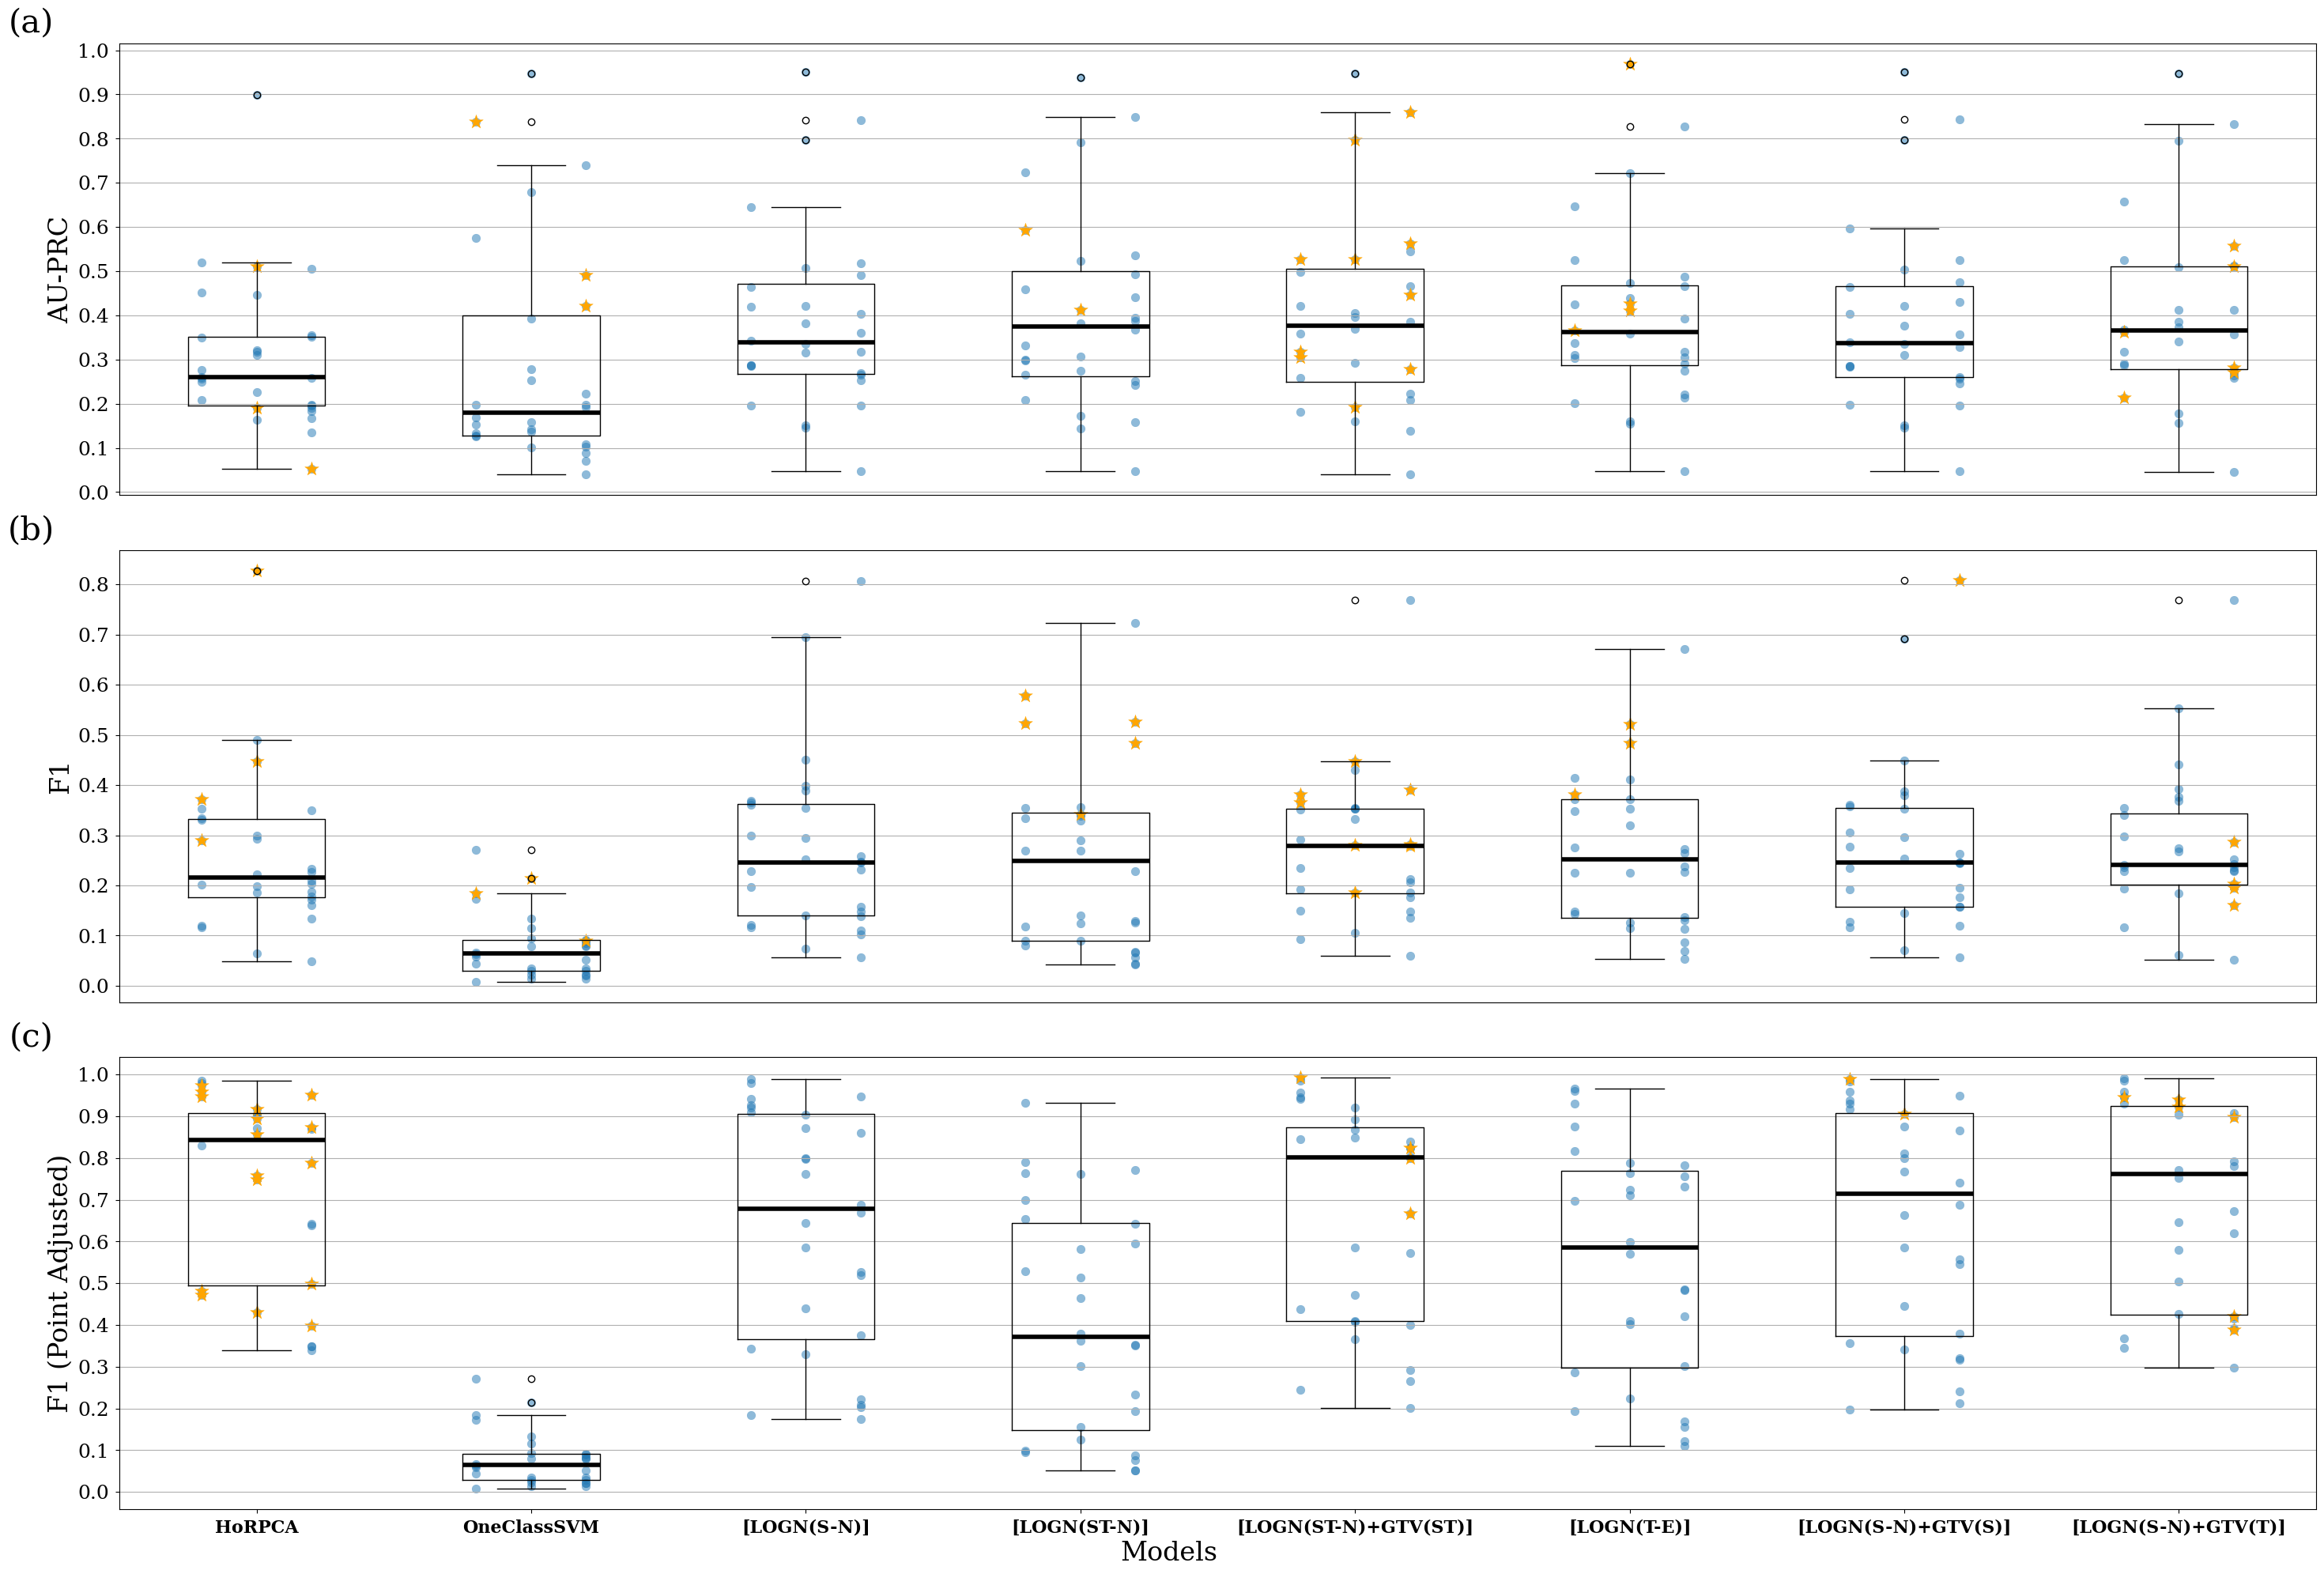

: 

In [26]:
machine_ids = [1, 2, 3]
num_channels = {1:8, 2: 9, 3: 11}
# Boxplot Settings
boxplot_cfg = {'medianprops': {'color': 'black', 'linewidth': 4},
            }
# Model Performance Scatter Settings
alpha=0.50; s=60; marker='o'
# Best Model Scatter Settings
best_marker = '*'; best_marker_size = s*3; best_marker_color = 'orange'
# Title Settings
title_settings = {'fontsize' :30, 'y': 1.01, 'x': -0.04}#, 'fontweight': 'bold'}
# X Label Settings
x_ticks_settings = {'fontsize': 16, 'rotation': 0, 'ha': 'center', 'va': 'top', 'y': 0, 'fontweight': 'bold'}
x_label_settings = {'fontsize': 24, 'rotation': 0, 'ha': 'right', 'va': 'top', 'y': -0.3, }#'fontweight': 'bold'}
y_label_settings = {'fontsize': 24, 'rotation': 'vertical', 'y': 0.5, 'x':-0.2, }#'fontweight': 'bold'}
y_ticks_settings = {'fontsize': 18}
fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(29, 20))
offsets = [-0.2, 0, 0.2]
colors = ['blue', 'orange', 'green']


xs = [[offsets[m-1]]*num_channels[m] for m in range(1, len(machine_ids) + 1)]
xs = [item for sublist in xs for item in sublist]
clrs =[[colors[m-1]]*num_channels[m] for m in range(1, len(machine_ids) + 1)]
clrs = [item for sublist in clrs for item in sublist]
clrs_per_model = [clrs for m in models]
xs_per_model = [np.array(xs) + m+1 for m in range(len(models))]
au_prc_list = [np.array(au_prcs[m]) for m in models]
au_roc_list = [np.array(au_rocs[m]) for m in models]
f1_list = [np.array(f1s[m]) for m in models]
pa_f1_list = [np.array(pa_f1s[m]) for m in models]
xs = [np.array(xs) + m for m in range(1, len(models)+1)]
# markers =['o', 's', '^', 'D', 'x', 'v', '*']
# colors = ['blue', 'orange', 'green', 'red', 'purple', 'brown', 'pink']
# axes[0].scatter(xs_per_model, au_rocs, marker=marker, s=s, alpha=alpha)
# axes[0].set_ylim(0, 1.05)
axes[0].set_title('(a)',#'Area Under the Precision-Recall Curve Scores of Different Models',
                    **title_settings)
axes[0].scatter(xs_per_model, au_prc_list, marker=marker, s=s, alpha=alpha)
axes[0].boxplot(au_prc_list, **boxplot_cfg)

axes[1].set_title('(b)',# 'F1 Scores of Different Models',
                    **title_settings)
axes[1].scatter(xs_per_model, f1_list, marker=marker, s=s, alpha=alpha)
axes[1].boxplot(f1_list, **boxplot_cfg)

axes[2].set_title('(c)', #'Point Adjusted F1 Scores of Different Models', 
                  **title_settings)
axes[2].scatter(xs_per_model, pa_f1_list, marker='o', s=s, alpha=alpha)
axes[2].boxplot(pa_f1_list, **boxplot_cfg)
metrics = ['AU-PRC', 'F1', 'F1 (Point Adjusted)']



for i, ax in enumerate(axes):
    ax.yaxis.grid(True)
    ax.set_xticks([])
    # ax.set_yticks()
    ytick_locations = np.linspace(0, 1.0, 11)
    ytick_labels = [f'0.{i}' for i in range(0, 10)]+['1.0']
    # ax.set_yticklabels( ytick_labels, **y_ticks_settings)
    ax.set_yticks(ytick_locations, ytick_labels, **y_ticks_settings)
    ax.set_ylabel(metrics[i], **y_label_settings)

axes[-1].set_xticks([y + 1 for y in range(len(model_names))],
                  labels=[name.replace('[SNN]-', '') for name in model_names],
                  **x_ticks_settings)
axes[-1].set_xlabel('Models', **x_label_settings);

# Scatter stars for models that had the best score for each channel

# best_au_prc_models = np.argmax(np.array(au_prcs), axis=0)
# best_au_roc_models = np.argmax(np.array(au_rocs), axis=0)
# best_f1_models = np.argmax(np.array(pa_f1s), axis=0)#f1s), axis=0)
# best_pa_f1_models = np.argmax(np.array(pa_f1s), axis=0)
markers = ['*']*len(model_names)
marker_sizes = [best_marker_size]*len(model_names)

for ch in range(len(best_au_prc_models)):
    best_auprc_model = best_au_prc_models[ch]
    best_auprc_model_number = model_numbers[best_auprc_model]

    
    axes[0].scatter(xs[best_auprc_model_number][ch], best_au_prc_values.iloc[ch],
                    marker=best_marker, s=best_marker_size, color=best_marker_color)
    
    best_f1_model = best_f1_models[ch]
    best_f1_model_number = model_numbers[best_f1_model]
    axes[1].scatter(xs[best_f1_model_number][ch], best_f1_values.iloc[ch],
                    marker=best_marker, s=best_marker_size, color=best_marker_color)
    
    best_pa_f1_model = best_pa_f1_models[ch]
    best_pa_f1_model_number = model_numbers[best_pa_f1_model]
    axes[2].scatter(xs[best_pa_f1_model_number][ch], best_pa_f1_values.iloc[ch],
                    marker=best_marker, s=best_marker_size, color=best_marker_color)

fig.tight_layout()

In [101]:
# xs_per_model[]
best_au_prc_models

Machine_Channel
(1, 1)            SNN_LOGNST
(1, 2)     SNN_LOGN_SN_GTV_T
(1, 3)      SNN_LOGNST_GTVST
(1, 4)      SNN_LOGNST_GTVST
(1, 5)          SNN_L1_GTV_T
(1, 6)           OneClassSVM
(1, 7)          SNN_L1_GTV_T
(1, 8)            SNN_LOGNTE
(2, 1)          SNN_L1_GTV_T
(2, 2)          SNN_L1_GTV_T
(2, 3)            SNN_LOGNST
(2, 4)            SNN_LOGNTE
(2, 5)        SNN_L1_GTVS_sn
(2, 6)            SNN_LOGNST
(2, 7)              SNN_LOGN
(2, 8)            SNN_LOGNTE
(2, 9)            SNN_LOGNTE
(3, 1)      SNN_LOGNST_GTVST
(3, 10)     SNN_LOGNST_GTVST
(3, 11)    SNN_LOGN_SN_GTV_T
(3, 2)        SNN_L1_GTVS_sn
(3, 3)     SNN_LOGN_SN_GTV_T
(3, 4)     SNN_LOGN_SN_GTV_T
(3, 5)     SNN_LOGN_SN_GTV_T
(3, 6)           OneClassSVM
(3, 7)     SNN_LOGN_SN_GTV_T
(3, 8)           OneClassSVM
(3, 9)      SNN_LOGNST_GTVST
dtype: object

/tmp/ipykernel_133531/523664602.py:75: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  best_auprc_model = best_au_prc_models[ch]
/tmp/ipykernel_133531/523664602.py:82: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  best_f1_model = best_f1_models[ch]
/tmp/ipykernel_133531/523664602.py:87: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  best_pa_f1_model = best_pa_f1_models[ch]


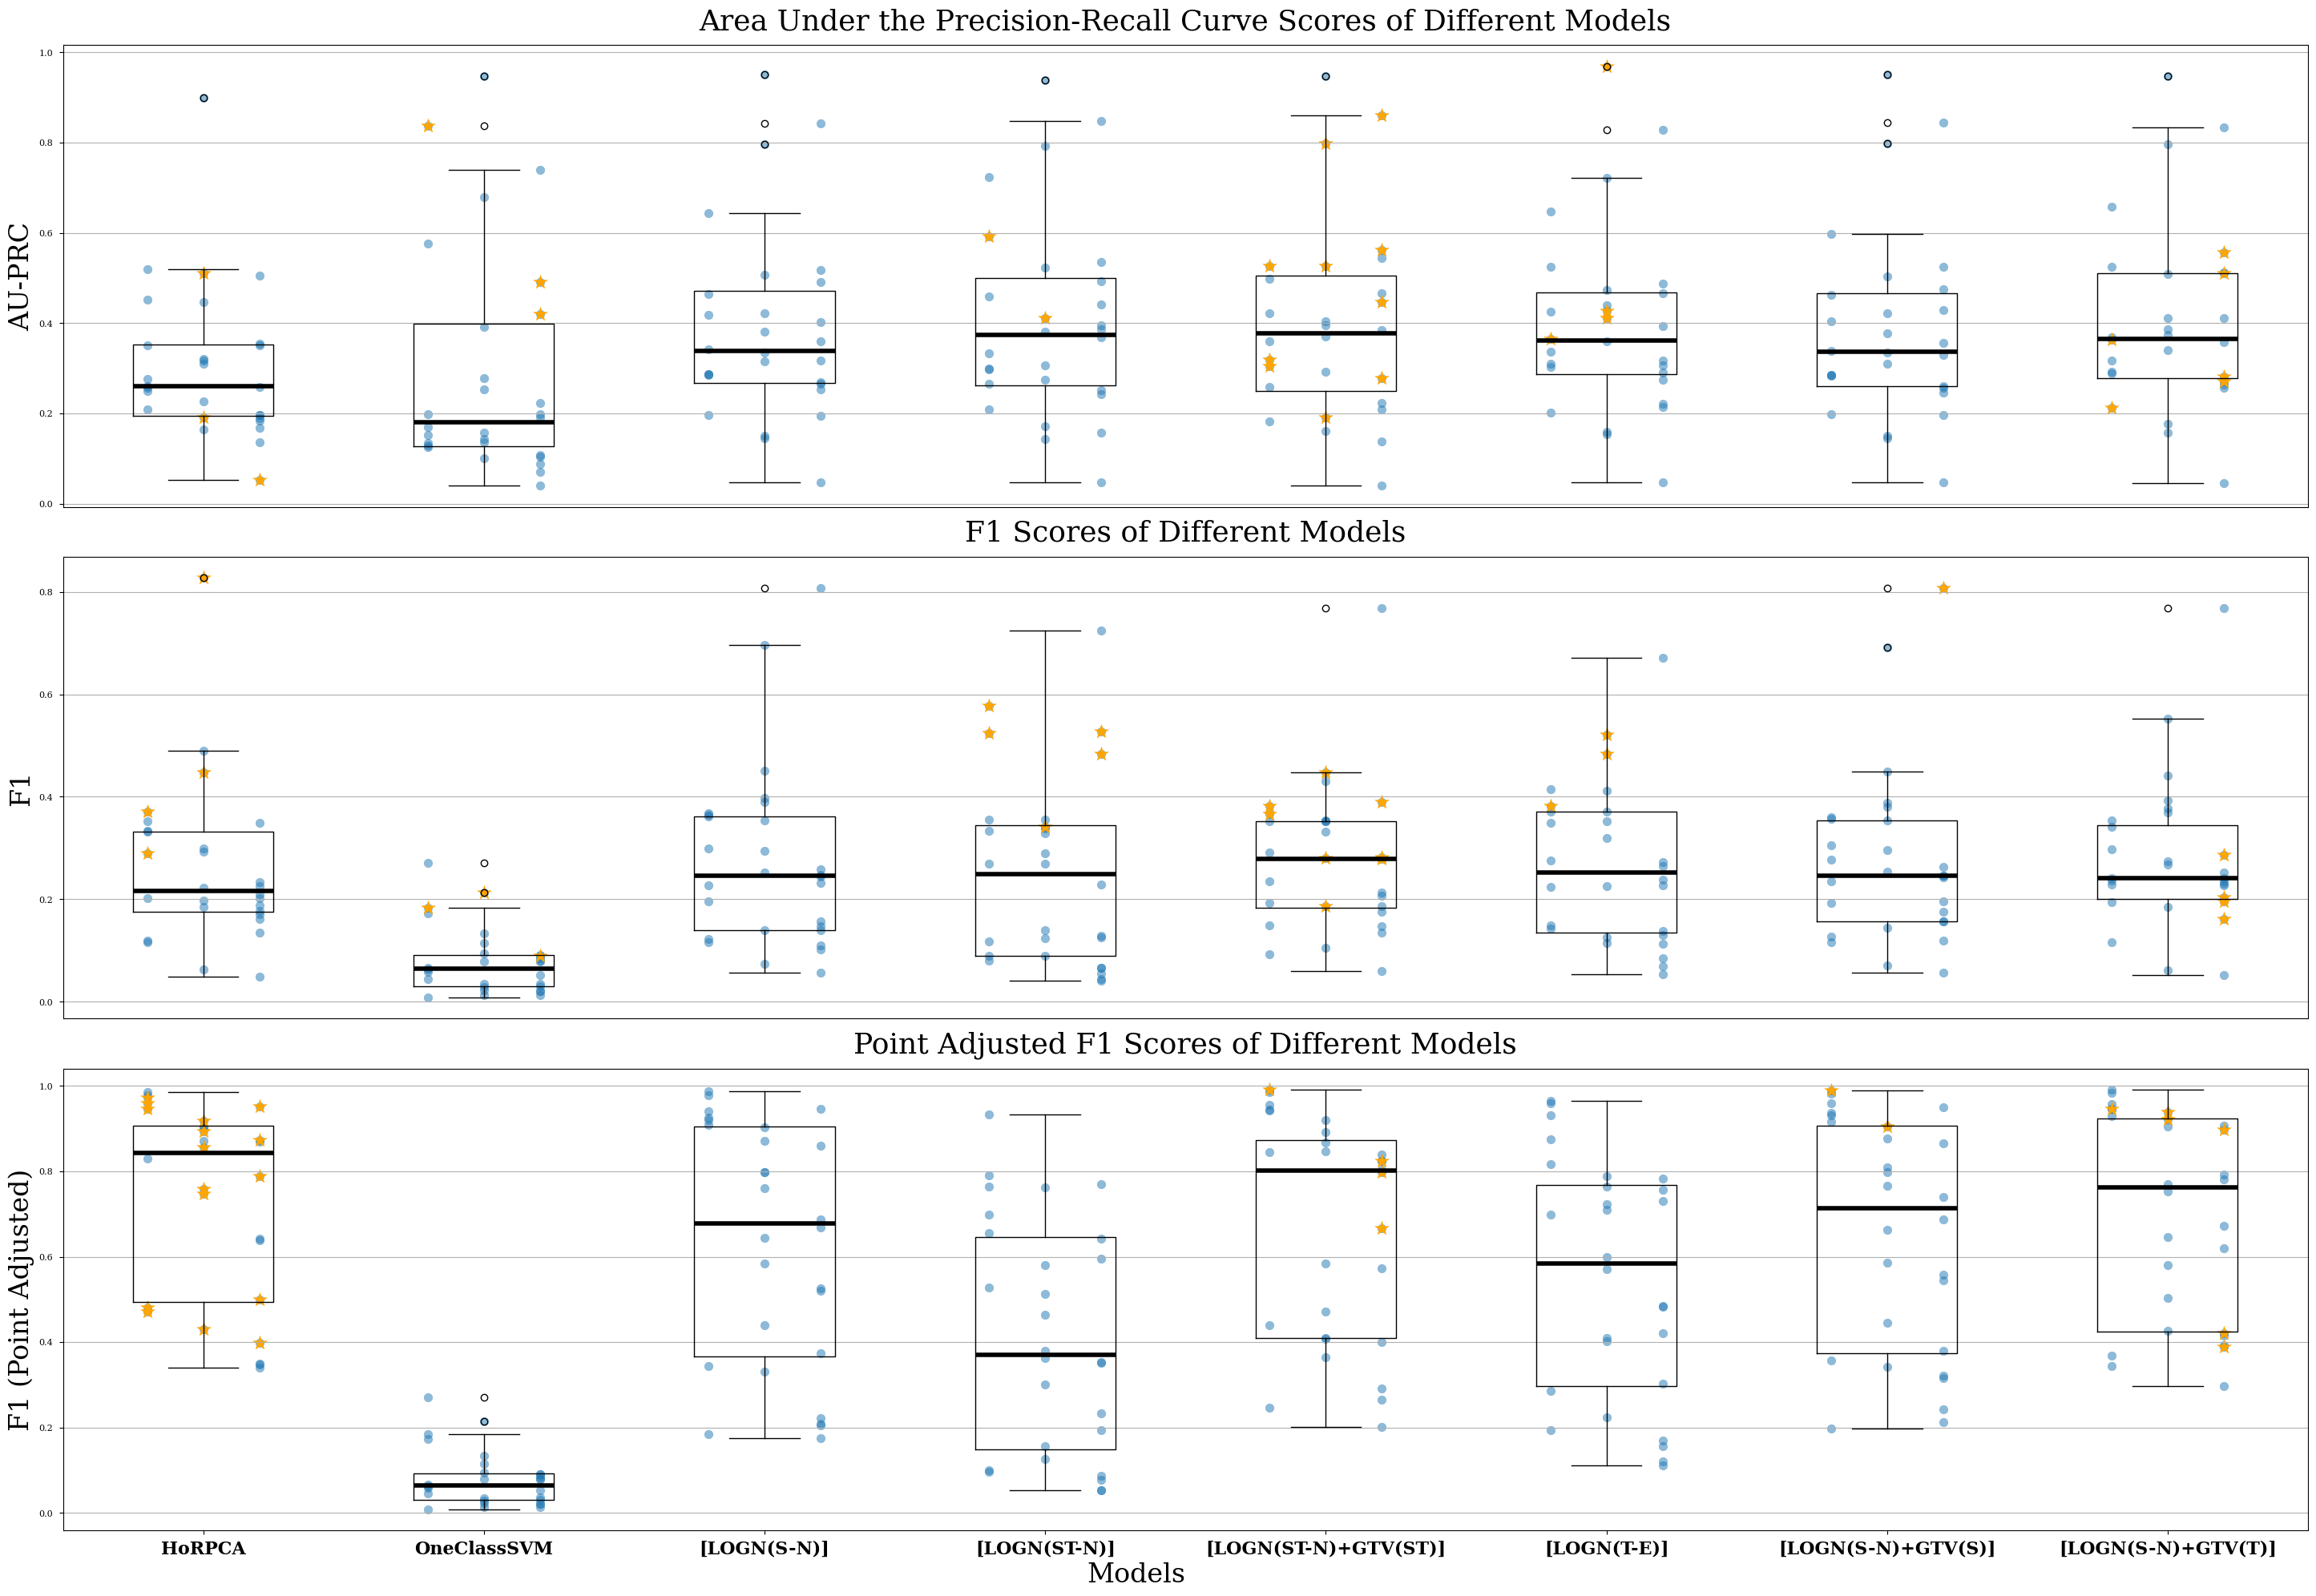

: 

In [ ]:
machine_ids = [1, 2, 3]
num_channels = {1:8, 2: 9, 3: 11}
# Boxplot Settings
boxplot_cfg = {'medianprops': {'color': 'black', 'linewidth': 4},
            }
# Model Performance Scatter Settings
alpha=0.50; s=60; marker='o'
# Best Model Scatter Settings
best_marker = '*'; best_marker_size = s*3; best_marker_color = 'orange'
# Title Settings
title_settings = {'fontsize' :26, 'y': 1.02} # 'fontweight': 'bold', 
# X Label Settings
x_ticks_settings = {'fontsize': 16, 'rotation': 0, 'ha': 'center', 'va': 'top', 'y': 0, 'fontweight': 'bold'}
x_label_settings = {'fontsize': 24, 'rotation': 0, 'ha': 'right', 'va': 'top', 'y': -0.3, }#'fontweight': 'bold'}
y_label_settings = {'fontsize': 24, 'rotation': 'vertical', 'y': 0.5, 'x':-0.2, }#'fontweight': 'bold'}
y_ticks_settings = {'fontsize': 18}
fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(29, 20))
offsets = [-0.2, 0, 0.2]
colors = ['blue', 'orange', 'green']


xs = [[offsets[m-1]]*num_channels[m] for m in range(1, len(machine_ids) + 1)]
xs = [item for sublist in xs for item in sublist]
clrs =[[colors[m-1]]*num_channels[m] for m in range(1, len(machine_ids) + 1)]
clrs = [item for sublist in clrs for item in sublist]
clrs_per_model = [clrs for m in models]
xs_per_model = [np.array(xs) + m+1 for m in range(len(models))]
au_prc_list = [np.array(au_prcs[m]) for m in models]
au_roc_list = [np.array(au_rocs[m]) for m in models]
f1_list = [np.array(f1s[m]) for m in models]
pa_f1_list = [np.array(pa_f1s[m]) for m in models]
xs = [np.array(xs) + m for m in range(1, len(models)+1)]
# markers =['o', 's', '^', 'D', 'x', 'v', '*']
# colors = ['blue', 'orange', 'green', 'red', 'purple', 'brown', 'pink']
# axes[0].scatter(xs_per_model, au_rocs, marker=marker, s=s, alpha=alpha)
# axes[0].set_ylim(0, 1.05)
axes[0].set_title('Area Under the Precision-Recall Curve Scores of Different Models', **title_settings)
axes[0].scatter(xs_per_model, au_prc_list, marker=marker, s=s, alpha=alpha)
axes[0].boxplot(au_prc_list, **boxplot_cfg)

axes[1].set_title('F1 Scores of Different Models', **title_settings)
axes[1].scatter(xs_per_model, f1_list, marker=marker, s=s, alpha=alpha)
axes[1].boxplot(f1_list, **boxplot_cfg)

axes[2].set_title('Point Adjusted F1 Scores of Different Models', **title_settings)
axes[2].scatter(xs_per_model, pa_f1_list, marker='o', s=s, alpha=alpha)
axes[2].boxplot(pa_f1_list, **boxplot_cfg)
metrics = ['AU-PRC', 'F1', 'F1 (Point Adjusted)']



for i, ax in enumerate(axes):
    ax.yaxis.grid(True)
    ax.set_xticks([])
    # ax.set_yticks()
    # ytick_labels = [f'0.{i}' for i in range(0, 10)]+['1.0']
    # ax.set_yticklabels(ytick_labels, **y_ticks_settings)
    ax.s
    ax.set_ylabel(metrics[i], **y_label_settings)

axes[-1].set_xticks([y + 1 for y in range(len(model_names))],
                  labels=[name.replace('[SNN]-', '') for name in model_names],
                  **x_ticks_settings)
axes[-1].set_xlabel('Models', **x_label_settings);

# Scatter stars for models that had the best score for each channel

# best_au_prc_models = np.argmax(np.array(au_prcs), axis=0)
# best_au_roc_models = np.argmax(np.array(au_rocs), axis=0)
# best_f1_models = np.argmax(np.array(pa_f1s), axis=0)#f1s), axis=0)
# best_pa_f1_models = np.argmax(np.array(pa_f1s), axis=0)
markers = ['*']*len(model_names)
marker_sizes = [best_marker_size]*len(model_names)

for ch in range(len(best_au_prc_models)):
    best_auprc_model = best_au_prc_models[ch]
    best_auprc_model_number = model_numbers[best_auprc_model]

    
    axes[0].scatter(xs[best_auprc_model_number][ch], best_au_prc_values.iloc[ch],
                    marker=best_marker, s=best_marker_size, color=best_marker_color)
    
    best_f1_model = best_f1_models[ch]
    best_f1_model_number = model_numbers[best_f1_model]
    axes[1].scatter(xs[best_f1_model_number][ch], best_f1_values.iloc[ch],
                    marker=best_marker, s=best_marker_size, color=best_marker_color)
    
    best_pa_f1_model = best_pa_f1_models[ch]
    best_pa_f1_model_number = model_numbers[best_pa_f1_model]
    axes[2].scatter(xs[best_pa_f1_model_number][ch], best_pa_f1_values.iloc[ch],
                    marker=best_marker, s=best_marker_size, color=best_marker_color)

fig.tight_layout()

In [ ]:
model_indices = [i for i in range(len(model_names))]
print(np.argmin(np.array(gics), axis=0))
print(np.argmax(np.array(au_prcs), axis=0))
print(np.argmax(np.array(au_rocs), axis=0))
print(np.argmax(np.array(f1s), axis=0))
model_best_au_prcs = [sum(np.argmax(np.array(au_prcs), axis=0) ==i) for i in model_indices]
model_best_au_rocs = [sum(np.argmax(np.array(au_rocs), axis=0) ==i) for i in model_indices]
model_best_gics = [sum(np.argmin(np.array(gics), axis=0) ==i) for i in model_indices]
model_best_f1s = [sum(np.argmax(np.array(f1s), axis=0) ==i) for i in model_indices]
print("Number of times each model had the best AU-PRC score:")
pprint({model_names[i]: model_best_au_prcs[i].item() for i in model_indices})
print("Number of times each model had the best AU-ROC score:")
pprint({model_names[i]: model_best_au_rocs[i].item() for i in model_indices})
# print("Number of times each model had the best GIC score:")
# pprint({model_names[i]: model_best_gics[i].item() for i in model_indices})
print("Number of times each model had the best F1 score:")
pprint({model_names[i]: model_best_f1s[i].item() for i in model_indices})
pprint({'Average AU-PRC': {model_names[i]: np.mean(au_prcs[i]).item() for i in model_indices},
        'Average AU-ROC': {model_names[i]: np.mean(au_rocs[i]).item() for i in model_indices},
        'Average F1': {model_names[i]: np.mean(f1s[i]).item() for i in model_indices},
        'Average PA-F1': {model_names[i]: np.mean(pa_f1s[i]).item() for i in model_indices},
        'Median AU-PRC': {model_names[i]: np.median(au_prcs[i]).item() for i in model_indices},
        'Median AU-ROC': {model_names[i]: np.median(au_rocs[i]).item() for i in model_indices},
        'Median F1': {model_names[i]: np.median(f1s[i]).item() for i in model_indices},
        'Median PA-F1': {model_names[i]: np.median(pa_f1s[i]).item() for i in model_indices},
})

[3 6 3 2 0 2 2 6 6 2 3 2 2 2 2 2 6 0 6 2 3 2 3 3 2 6 2 2]
[0 2 5 5 2 2 2 5 2 1 2 2 1 5 3 2 5 2 3 5 2 3 6 1 5 5 5 1]
[5 3 2 3 2 1 6 5 2 1 1 5 1 3 5 5 2 0 5 5 2 5 5 1 5 3 5 3]
[6 6 5 5 6 1 6 5 1 3 1 2 3 2 3 6 5 4 5 5 5 6 5 3 0 5 6 0]
Number of times each model had the best AU-PRC score:
{'HoRPCA': 1,
 '[SNN]-[L1+GTV(S)]': 1,
 '[SNN]-[L1+GTV(T)]': 10,
 '[SNN]-[LOGN(S-N)+GTV(T)]': 3,
 '[SNN]-[LOGN(S-N)]': 0,
 '[SNN]-[LOGN(ST-N)]': 9,
 '[SNN]-[LOGN(T-E)]': 4}
Number of times each model had the best AU-ROC score:
{'HoRPCA': 1,
 '[SNN]-[L1+GTV(S)]': 1,
 '[SNN]-[L1+GTV(T)]': 5,
 '[SNN]-[LOGN(S-N)+GTV(T)]': 5,
 '[SNN]-[LOGN(S-N)]': 0,
 '[SNN]-[LOGN(ST-N)]': 11,
 '[SNN]-[LOGN(T-E)]': 5}
Number of times each model had the best F1 score:
{'HoRPCA': 2,
 '[SNN]-[L1+GTV(S)]': 7,
 '[SNN]-[L1+GTV(T)]': 2,
 '[SNN]-[LOGN(S-N)+GTV(T)]': 4,
 '[SNN]-[LOGN(S-N)]': 1,
 '[SNN]-[LOGN(ST-N)]': 9,
 '[SNN]-[LOGN(T-E)]': 3}
{'Average AU-PRC': {'HoRPCA': 0.4604324279865827,
                    '[SNN]-[L1+GTV(S)]': 0

In [ ]:
import optuna
# HoRPCA,SNN_LOGNTE,SNN_LOGN,SNN_L1_GTV_T,SNN_LOGNST,SNN_L1_GTVS,SNN_LOGN_SN_GTV_T
model_keys = ['HoRPCA','SNN_LOGNTE','SNN_L1_GTV_T', 'SNN_LOGN_SN_GTV_T', 'SNN_LOGN', 'SNN_LOGNST','SNN_L1_GTVS']
with open(CFG_DIR / 'model_configs.yaml') as f:
    model_configs = yaml.safe_load(f)

model_names = [ model_configs[key]['name'] for key in model_keys]
metrics = ['AU-ROC', 'AU-PRC', 'F1']

machine_ids = [1,2, 3]
num_channels = {1:8, 2: 9, 3: 11}
metric_name = 'gic_1_two_phase'
# metric_name = 'au_prc_two_phase'
# metric_name = 'au_prc_two_phase'

au_rocs = []
au_prcs = []
f1s = []
pa_f1s = []
gics = []
for m, model_name in enumerate(model_names):
    au_roc_model = []
    au_prc_model = []
    f1_model = []
    pa_f1_model = []
    gic_model = []
    for machine_id in machine_ids:
        for channel_id in range(1, num_channels[machine_id] + 1):
            study_name = model_name + f"_m{machine_id}_ch{channel_id}" + f"_scfg{metric_name}"
            storage = f'sqlite:///{RESULTS_DIR.absolute()}/{model_keys[m]}_m{machine_id}_ch{channel_id}.db'

            study = optuna.create_study(study_name=study_name,
                                        storage=storage,
                                        load_if_exists=True,
                                        direction='minimize')

            study_df = study.trials_dataframe()
            if study_df.empty:
                continue
            study_df= study_df.rename(columns=lambda x: x.replace('user_attrs_', '')
                            ).rename(columns=lambda x: x.replace('params_', '')
                            ).rename(columns=lambda x: x.replace('raw_', ''))

            
            # study_df = study_df.sort_values(by='au_prc', ascending=False)
            # study_df = study_df.sort_values(by='f1', ascending=False)
            try:
                study_df = study_df.sort_values(by='gic_6', ascending=True)
            except KeyError:
                study_df = study_df.sort_values(by='gic_6', ascending=True)

            best_trial = study_df.iloc[0]
            # print(best_trial)
            au_roc_model.append(best_trial['au_roc'])
            au_prc_model.append(best_trial['au_prc'])
            f1_model.append(best_trial['f1'])
            # pa_f1_model.append(best_trial['likelihood_au_prc'])
            pa_f1_model.append(best_trial['PA_F1'])
            gic_model.append(best_trial['gic_6'])
    au_rocs.append(au_roc_model)
    au_prcs.append(au_prc_model)
    f1s.append(f1_model)
    pa_f1s.append(pa_f1_model)
    gics.append(gic_model)

[I 2025-09-22 04:34:21,374] Using an existing study with name 'HoRPCA_m1_ch1_scfggic_1_two_phase' instead of creating a new one.
[I 2025-09-22 04:34:21,621] Using an existing study with name 'HoRPCA_m1_ch2_scfggic_1_two_phase' instead of creating a new one.
[I 2025-09-22 04:34:22,200] Using an existing study with name 'HoRPCA_m1_ch3_scfggic_1_two_phase' instead of creating a new one.
[I 2025-09-22 04:34:22,490] Using an existing study with name 'HoRPCA_m1_ch4_scfggic_1_two_phase' instead of creating a new one.
[I 2025-09-22 04:34:22,779] Using an existing study with name 'HoRPCA_m1_ch5_scfggic_1_two_phase' instead of creating a new one.
[I 2025-09-22 04:34:23,082] Using an existing study with name 'HoRPCA_m1_ch6_scfggic_1_two_phase' instead of creating a new one.
[I 2025-09-22 04:34:23,608] Using an existing study with name 'HoRPCA_m1_ch7_scfggic_1_two_phase' instead of creating a new one.
[I 2025-09-22 04:34:23,910] Using an existing study with name 'HoRPCA_m1_ch8_scfggic_1_two_phase'

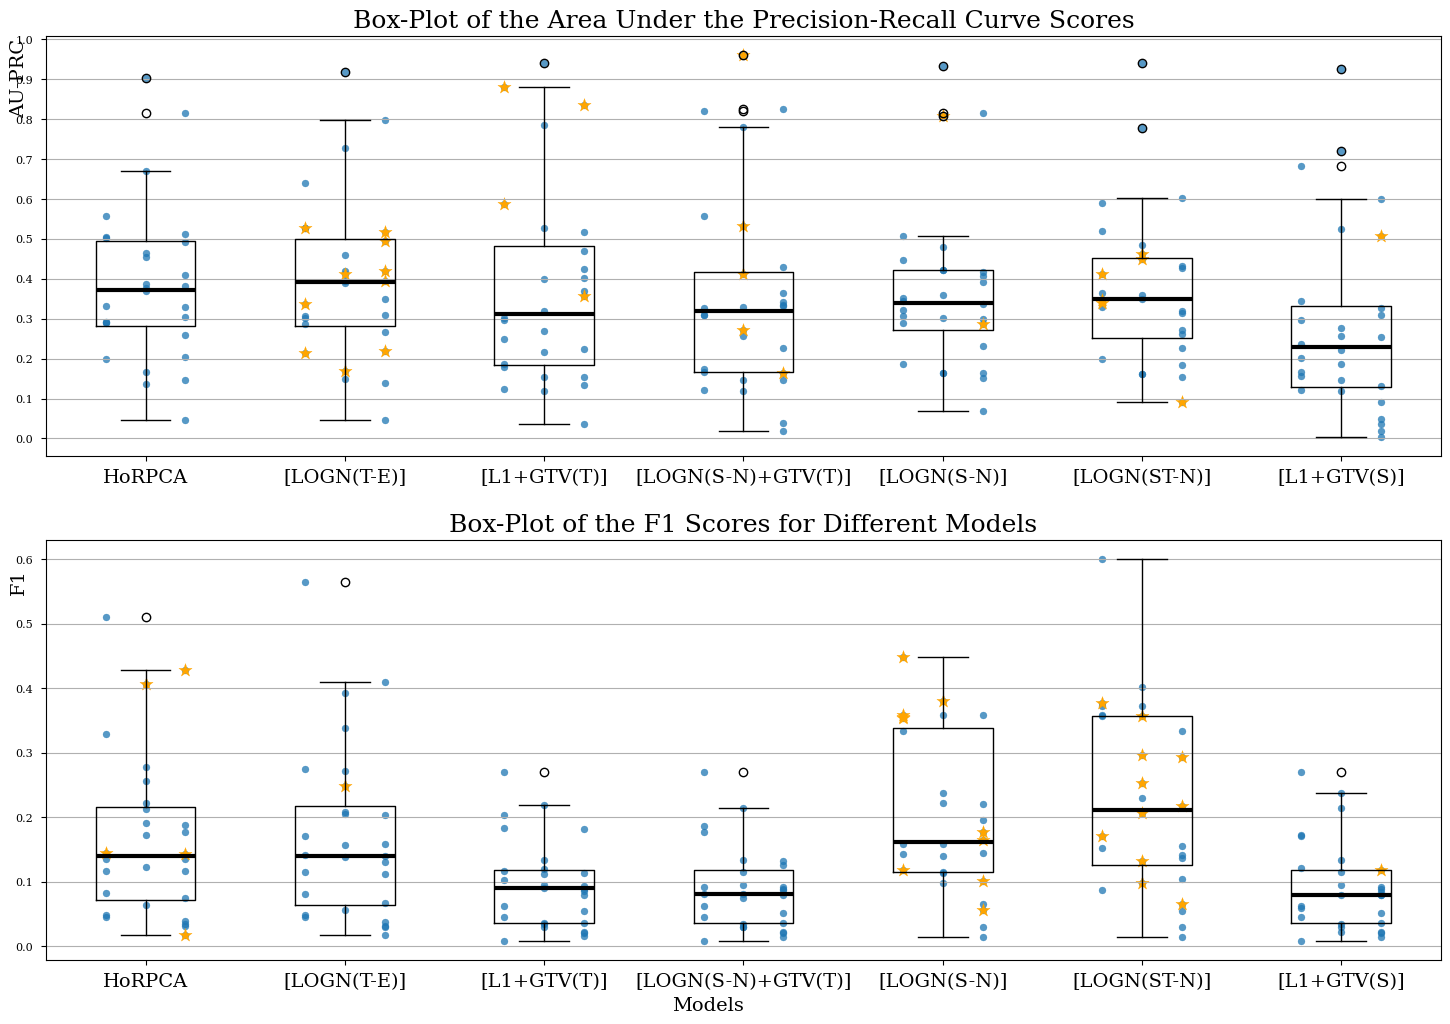

In [ ]:
# Boxplot Settings
boxplot_cfg = {'medianprops': {'color': 'black', 'linewidth': 3},
            }
# Model Performance Scatter Settings
alpha=0.75; s=25; marker='o'
# Best Model Scatter Settings
best_marker = '*'; best_marker_size = 100; best_marker_color = 'orange'
# Title Settings
title_settings = {'fontsize' :18 }
# X Label Settings
x_ticks_settings = {'fontsize': 14, 'rotation': 0, 'ha': 'center', 'va': 'top', 'y': 0}
x_label_settings = {'fontsize': 14, 'rotation': 0, 'ha': 'right', 'va': 'top', 'y': 0}
y_label_settings = {'fontsize': 14, 'rotation': 'vertical', 'y': 0.9, 'x':-0.2, 'va': 'top', 'ha': 'center'}
y_ticks_settings = {}
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(18, 12))
# fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(18, 22.5))
# axes[0].set_title('Area Under ROC Curve Scores for Different Models', **title_settings)
# axes[0].boxplot(au_rocs, **boxplot_cfg)
offsets = [-0.2, 0, 0.2]
colors = ['blue', 'orange', 'green']
xs = [[offsets[m-1]]*num_channels[m] for m in range(1, len(machine_ids) + 1)]
xs = [item for sublist in xs for item in sublist]
clrs =[[colors[m-1]]*num_channels[m] for m in range(1, len(machine_ids) + 1)]
clrs = [item for sublist in clrs for item in sublist]
clrs_per_model = [clrs for m in range(len(model_names))]
xs_per_model = [np.array(xs) + m+1 for m in range(len(model_names))]
au_prcs = [np.array(au_prcs[m]) for m in range(len(model_names))]
au_rocs = [np.array(au_rocs[m]) for m in range(len(model_names))]
# xs = [np.array(xs) + m for m in range(1, len(model_name)+1)]
# markers =['o', 's', '^', 'D', 'x', 'v', '*']
# colors = ['blue', 'orange', 'green', 'red', 'purple', 'brown', 'pink']
# axes[0].scatter(xs_per_model, au_rocs, marker=marker, s=s, alpha=alpha)
# axes[0].set_ylim(0, 1.05)
axes[0].set_title('Box-Plot of the Area Under the Precision-Recall Curve Scores', **title_settings)
axes[0].scatter(xs_per_model, au_prcs, marker=marker, s=s, alpha=alpha)
axes[0].boxplot(au_prcs, **boxplot_cfg)
axes[1].set_title('Box-Plot of the F1 Scores for Different Models', **title_settings)
axes[1].scatter(xs_per_model, f1s, marker=marker, s=s, alpha=alpha)
axes[1].boxplot(f1s, **boxplot_cfg)
# axes[2].set_title('Point Adjusted F1 Scores with likelihood for Different Models')
# axes[2].scatter(xs_per_model, pa_f1s, marker='o', s=25, alpha=alpha)
# axes[2].boxplot(pa_f1s, **boxplot_cfg)
metrics = ['AU-PRC', 'F1']#'l AU-ROC', 'l AU-PRC']
# metrics = ['AU-ROC', 'AU-PRC', 'F1 (Point Adjusted)']#'l AU-ROC', 'l AU-PRC']
# metrics = ['F1', 'PA_F1']
for i, ax in enumerate(axes):
    ax.yaxis.grid(True)
    ax.set_xticks([y + 1 for y in range(len(model_names))],
                  labels=[name.replace('[SNN]-', '') for name in model_names],
                  **x_ticks_settings)
    ax.set_yticks(np.arange(0, 1.1, 0.1), **y_ticks_settings)
    ax.set_ylabel(metrics[i], **y_label_settings)
axes[1].set_xlabel('Models', **x_label_settings);

# Scatter stars for models that had the best score for each channel

best_au_prc_models = np.argmax(np.array(au_prcs), axis=0)
best_au_roc_models = np.argmax(np.array(au_rocs), axis=0)
best_f1_models = np.argmax(np.array(pa_f1s), axis=0)#f1s), axis=0)
best_pa_f1_models = np.argmax(np.array(pa_f1s), axis=0)
markers = ['*']*len(model_names)
marker_sizes = [best_marker_size]*len(model_names)

for ch in range(len(xs)):
    # axes[0].scatter(xs[ch] + best_au_roc_models[ch]+1, au_rocs[best_au_roc_models[ch]][ch],
    #                 marker=markers[best_au_roc_models[ch]], s=marker_sizes[best_au_roc_models[ch]], color=best_marker_color)
    axes[0].scatter(xs[ch] + best_au_prc_models[ch]+1, au_prcs[best_au_prc_models[ch]][ch],
                    marker=markers[best_au_prc_models[ch]], s=marker_sizes[best_au_prc_models[ch]], color=best_marker_color)
    axes[1].scatter(xs[ch] + best_f1_models[ch]+1, f1s[best_f1_models[ch]][ch],
                    marker=markers[best_f1_models[ch]], s=marker_sizes[best_f1_models[ch]], color=best_marker_color)
    # axes[1].scatter(xs[ch] + best_pa_f1_models[ch]+1, pa_f1s[best_pa_f1_models[ch]][ch],
                    # marker=markers[best_pa_f1_models[ch]], s=marker_sizes[best_pa_f1_models[ch]], color=best_marker_color)


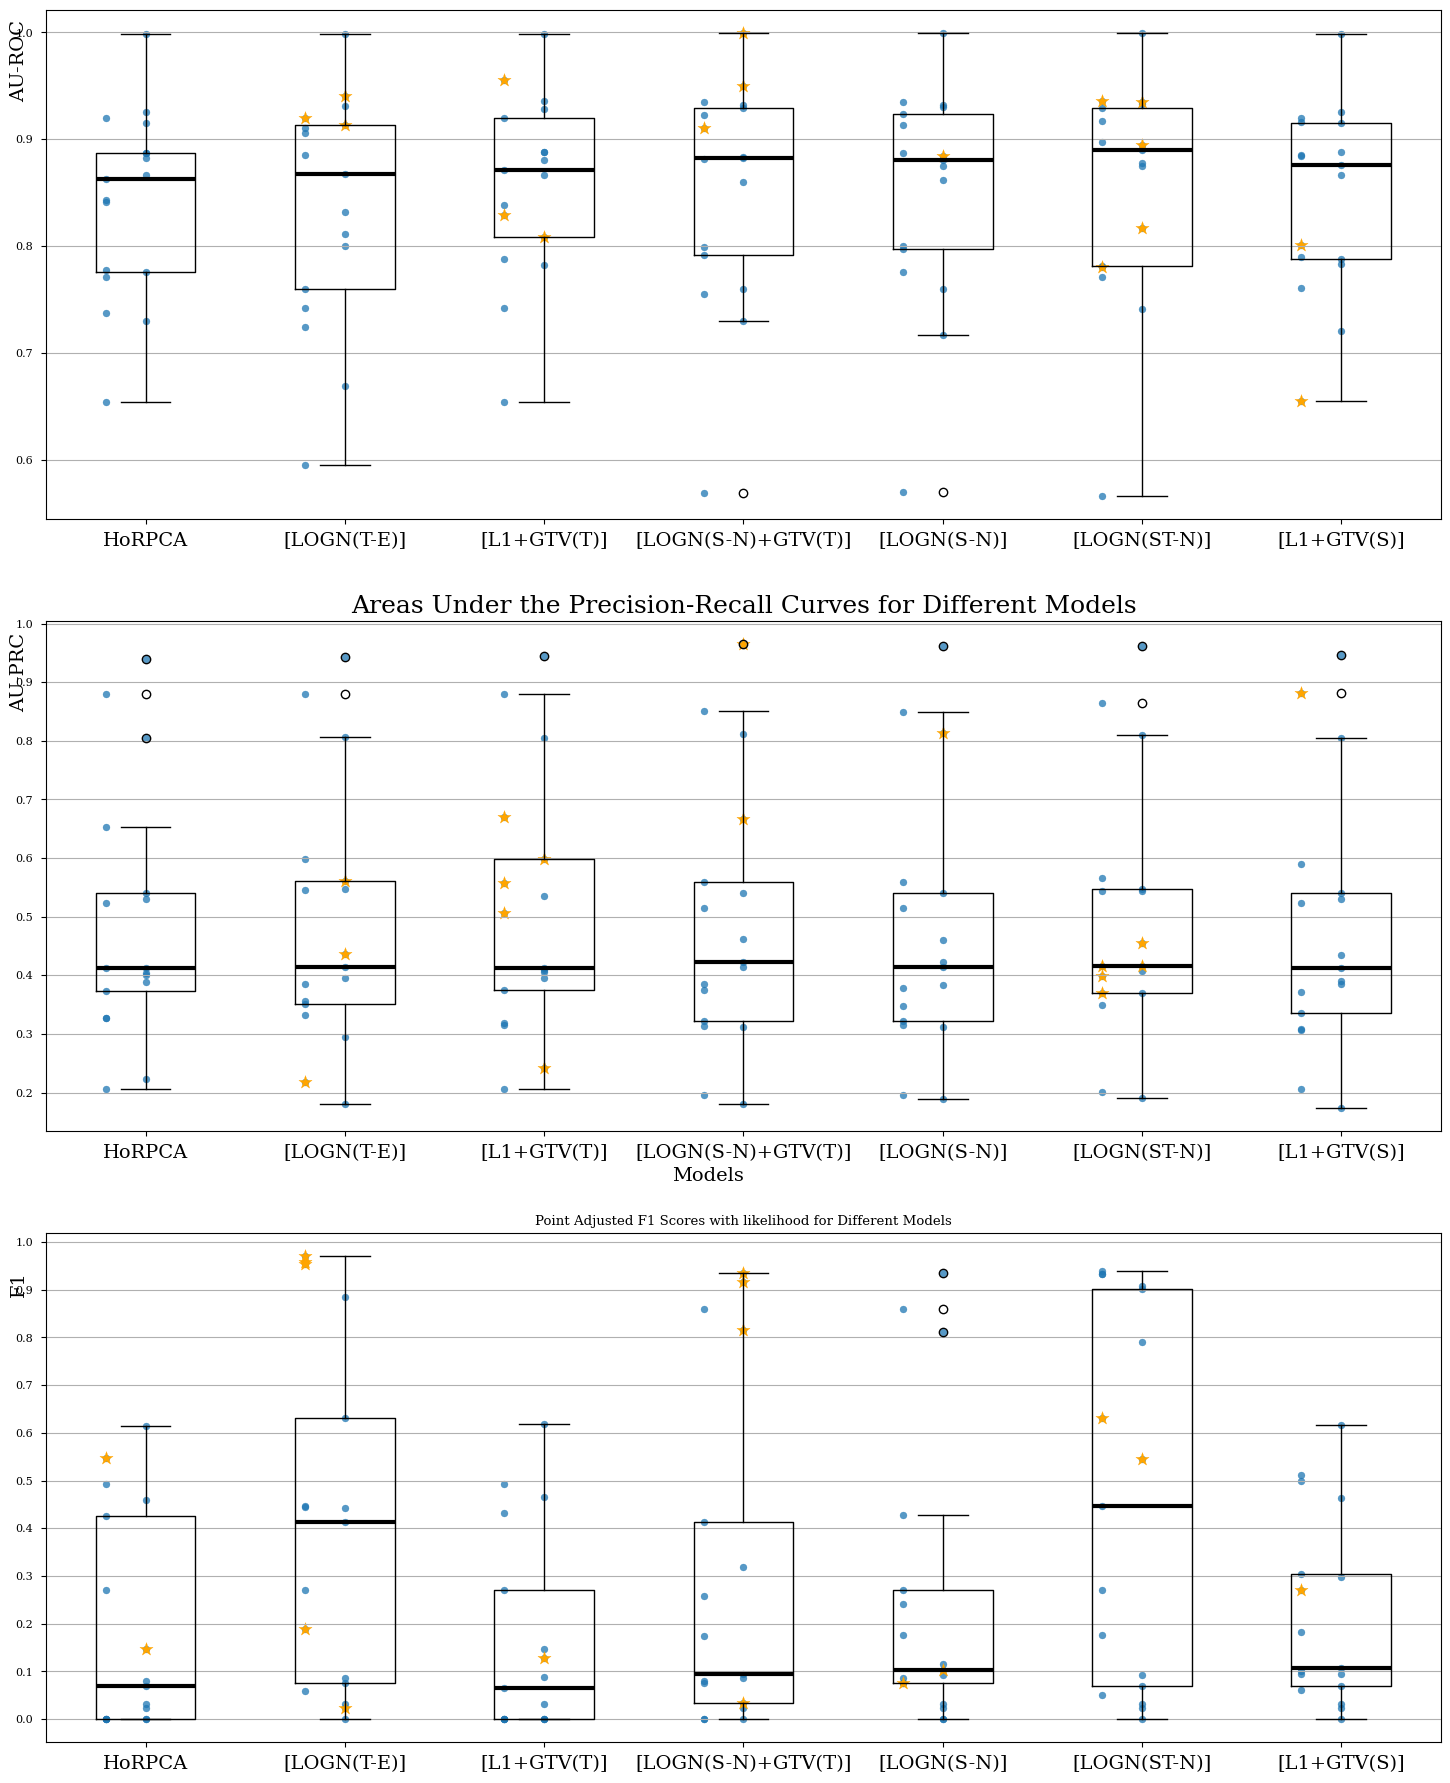

In [ ]:
# Boxplot Settings
boxplot_cfg = {'medianprops': {'color': 'black', 'linewidth': 3},
            }
# Model Performance Scatter Settings
alpha=0.75; s=25; marker='o'
# Best Model Scatter Settings
best_marker = '*'; best_marker_size = 100; best_marker_color = 'orange'
# Title Settings
title_settings = {'fontsize' :18 }
# X Label Settings
x_ticks_settings = {'fontsize': 14, 'rotation': 0, 'ha': 'center', 'va': 'top', 'y': 0}
x_label_settings = {'fontsize': 14, 'rotation': 0, 'ha': 'right', 'va': 'top', 'y': 0}
y_label_settings = {'fontsize': 14, 'rotation': 'vertical', 'y': 0.9, 'va': 'top', 'ha': 'center'}
y_ticks_settings = {}
# fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(18, 15))
fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(18, 22.5))
# axes[0].set_title('Area Under ROC Curve Scores for Different Models', **title_settings)
axes[0].boxplot(au_rocs, **boxplot_cfg)
offsets = [-0.2, 0, 0.2]
colors = ['blue', 'orange', 'green']
xs = [[offsets[m-1]]*num_channels[m] for m in range(1, len(machine_ids) + 1)]
xs = [item for sublist in xs for item in sublist]
clrs =[[colors[m-1]]*num_channels[m] for m in range(1, len(machine_ids) + 1)]
clrs = [item for sublist in clrs for item in sublist]
clrs_per_model = [clrs for m in range(len(model_names))]
xs_per_model = [np.array(xs) + m+1 for m in range(len(model_names))]
au_prcs = [np.array(au_prcs[m]) for m in range(len(model_names))]
au_rocs = [np.array(au_rocs[m]) for m in range(len(model_names))]
# xs = [np.array(xs) + m for m in range(1, len(model_name)+1)]
# markers =['o', 's', '^', 'D', 'x', 'v', '*']
# colors = ['blue', 'orange', 'green', 'red', 'purple', 'brown', 'pink']
axes[0].scatter(xs_per_model, au_rocs, marker=marker, s=s, alpha=alpha)
# axes[0].set_ylim(0, 1.05)
axes[1].set_title('Areas Under the Precision-Recall Curves for Different Models', **title_settings)
axes[1].scatter(xs_per_model, au_prcs, marker=marker, s=s, alpha=alpha)
axes[1].boxplot(au_prcs, **boxplot_cfg)
# axes[2].set_title('F1 Scores for Different Models')
# axes[2].scatter(xs_per_model, f1s, marker=marker, s=s, alpha=alpha)
# axes[2].boxplot(f1s, **boxplot_cfg)
axes[2].set_title('Point Adjusted F1 Scores with likelihood for Different Models')
axes[2].scatter(xs_per_model, pa_f1s, marker='o', s=25, alpha=alpha)
axes[2].boxplot(pa_f1s, **boxplot_cfg)
metrics = ['AU-ROC', 'AU-PRC', 'F1']#'l AU-ROC', 'l AU-PRC']
# metrics = ['AU-ROC', 'AU-PRC', 'F1 (Point Adjusted)']#'l AU-ROC', 'l AU-PRC']
# metrics = ['F1', 'PA_F1']
for i, ax in enumerate(axes):
    ax.yaxis.grid(True)
    ax.set_xticks([y + 1 for y in range(len(model_names))],
                  labels=[name.replace('[SNN]-', '') for name in model_names],
                  **x_ticks_settings)
    ax.set_yticks(np.arange(0, 1.1, 0.1), **y_ticks_settings)
    ax.set_ylabel(metrics[i], **y_label_settings)
axes[1].set_xlabel('Models', **x_label_settings);

# Scatter stars for models that had the best score for each channel

best_au_prc_models = np.argmax(np.array(au_prcs), axis=0)
best_au_roc_models = np.argmax(np.array(au_rocs), axis=0)
best_f1_models = np.argmax(np.array(pa_f1s), axis=0)#f1s), axis=0)
best_pa_f1_models = np.argmax(np.array(pa_f1s), axis=0)
markers = ['*']*len(model_names)
marker_sizes = [best_marker_size]*len(model_names)

for ch in range(len(xs)):
    axes[0].scatter(xs[ch] + best_au_roc_models[ch]+1, au_rocs[best_au_roc_models[ch]][ch],
                    marker=markers[best_au_roc_models[ch]], s=marker_sizes[best_au_roc_models[ch]], color=best_marker_color)
    axes[1].scatter(xs[ch] + best_au_prc_models[ch]+1, au_prcs[best_au_prc_models[ch]][ch],
                    marker=markers[best_au_prc_models[ch]], s=marker_sizes[best_au_prc_models[ch]], color=best_marker_color)
    # axes[2].scatter(xs[ch] + best_f1_models[ch]+1, f1s[best_f1_models[ch]][ch],
    #                 marker=markers[best_f1_models[ch]], s=marker_sizes[best_f1_models[ch]], color=best_marker_color)
    axes[2].scatter(xs[ch] + best_pa_f1_models[ch]+1, pa_f1s[best_pa_f1_models[ch]][ch],
                    marker=markers[best_pa_f1_models[ch]], s=marker_sizes[best_pa_f1_models[ch]], color=best_marker_color)


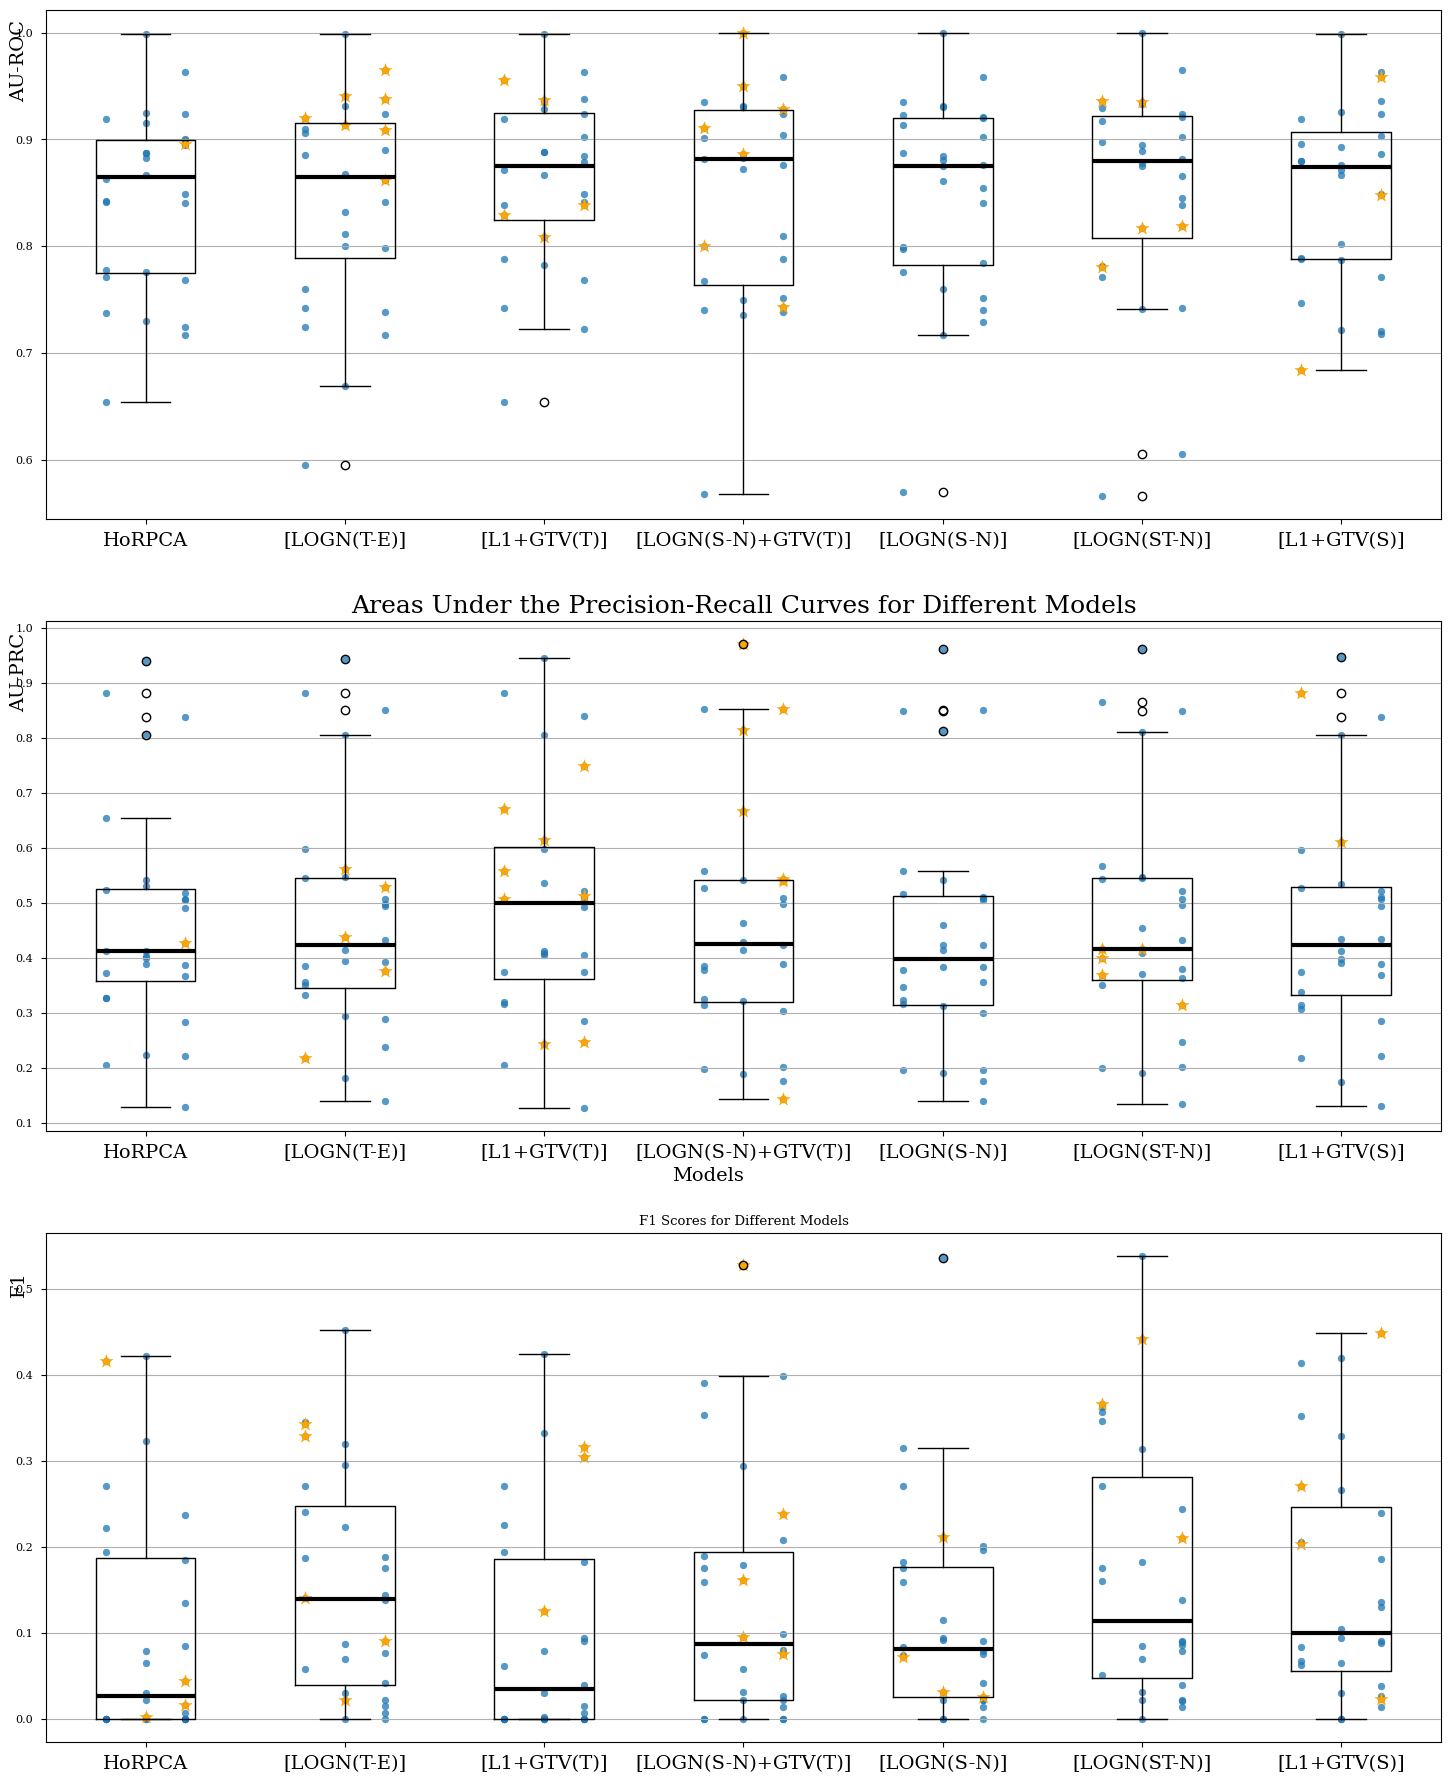

In [ ]:
# Boxplot Settings
boxplot_cfg = {'medianprops': {'color': 'black', 'linewidth': 3},
            }
# Model Performance Scatter Settings
alpha=0.75; s=25; marker='o'
# Best Model Scatter Settings
best_marker = '*'; best_marker_size = 100; best_marker_color = 'orange'
# Title Settings
title_settings = {'fontsize' :18 }
# X Label Settings
x_ticks_settings = {'fontsize': 14, 'rotation': 0, 'ha': 'center', 'va': 'top', 'y': 0}
x_label_settings = {'fontsize': 14, 'rotation': 0, 'ha': 'right', 'va': 'top', 'y': 0}
y_label_settings = {'fontsize': 14, 'rotation': 'vertical', 'y': 0.9, 'va': 'top', 'ha': 'center'}
y_ticks_settings = {}
# fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(18, 15))
fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(18, 22.5))
# axes[0].set_title('Area Under ROC Curve Scores for Different Models', **title_settings)
axes[0].boxplot(au_rocs, **boxplot_cfg)
offsets = [-0.2, 0, 0.2]
colors = ['blue', 'orange', 'green']
xs = [[offsets[m-1]]*num_channels[m] for m in range(1, len(machine_ids) + 1)]
xs = [item for sublist in xs for item in sublist]
clrs =[[colors[m-1]]*num_channels[m] for m in range(1, len(machine_ids) + 1)]
clrs = [item for sublist in clrs for item in sublist]
clrs_per_model = [clrs for m in range(len(model_names))]
xs_per_model = [np.array(xs) + m+1 for m in range(len(model_names))]
au_prcs = [np.array(au_prcs[m]) for m in range(len(model_names))]
au_rocs = [np.array(au_rocs[m]) for m in range(len(model_names))]
# xs = [np.array(xs) + m for m in range(1, len(model_name)+1)]
# markers =['o', 's', '^', 'D', 'x', 'v', '*']
# colors = ['blue', 'orange', 'green', 'red', 'purple', 'brown', 'pink']
axes[0].scatter(xs_per_model, au_rocs, marker=marker, s=s, alpha=alpha)
# axes[0].set_ylim(0, 1.05)
axes[1].set_title('Areas Under the Precision-Recall Curves for Different Models', **title_settings)
axes[1].scatter(xs_per_model, au_prcs, marker=marker, s=s, alpha=alpha)
axes[1].boxplot(au_prcs, **boxplot_cfg)
axes[2].set_title('F1 Scores for Different Models')
axes[2].scatter(xs_per_model, f1s, marker=marker, s=s, alpha=alpha)
axes[2].boxplot(f1s, **boxplot_cfg)
# axes[2].set_title('Point Adjusted F1 Scores with likelihood for Different Models')
# axes[2].scatter(xs_per_model, pa_f1s, marker='o', s=25, alpha=alpha)
# axes[2].boxplot(pa_f1s, **boxplot_cfg)
metrics = ['AU-ROC', 'AU-PRC', 'F1']#'l AU-ROC', 'l AU-PRC']
# metrics = ['AU-ROC', 'AU-PRC', 'F1 (Point Adjusted)']#'l AU-ROC', 'l AU-PRC']
# metrics = ['F1', 'PA_F1']
for i, ax in enumerate(axes):
    ax.yaxis.grid(True)
    ax.set_xticks([y + 1 for y in range(len(model_names))],
                  labels=[name.replace('[SNN]-', '') for name in model_names],
                  **x_ticks_settings)
    ax.set_yticks(np.arange(0, 1.1, 0.1), **y_ticks_settings)
    ax.set_ylabel(metrics[i], **y_label_settings)
axes[1].set_xlabel('Models', **x_label_settings);

# Scatter stars for models that had the best score for each channel

best_au_prc_models = np.argmax(np.array(au_prcs), axis=0)
best_au_roc_models = np.argmax(np.array(au_rocs), axis=0)
best_f1_models = np.argmax(np.array(pa_f1s), axis=0)#f1s), axis=0)
best_pa_f1_models = np.argmax(np.array(pa_f1s), axis=0)
markers = ['*']*len(model_names)
marker_sizes = [best_marker_size]*len(model_names)

for ch in range(len(xs)):
    axes[0].scatter(xs[ch] + best_au_roc_models[ch]+1, au_rocs[best_au_roc_models[ch]][ch],
                    marker=markers[best_au_roc_models[ch]], s=marker_sizes[best_au_roc_models[ch]], color=best_marker_color)
    axes[1].scatter(xs[ch] + best_au_prc_models[ch]+1, au_prcs[best_au_prc_models[ch]][ch],
                    marker=markers[best_au_prc_models[ch]], s=marker_sizes[best_au_prc_models[ch]], color=best_marker_color)
    axes[2].scatter(xs[ch] + best_f1_models[ch]+1, f1s[best_f1_models[ch]][ch],
                    marker=markers[best_f1_models[ch]], s=marker_sizes[best_f1_models[ch]], color=best_marker_color)
    # axes[2].scatter(xs[ch] + best_pa_f1_models[ch]+1, pa_f1s[best_pa_f1_models[ch]][ch],
    #                 marker=markers[best_pa_f1_models[ch]], s=marker_sizes[best_pa_f1_models[ch]], color=best_marker_color)
